In [1]:
# =============================================================================
# STEP 1: LOAD PROCESSED DATASET
# =============================================================================

import pandas as pd
import numpy as np


# Load cleaned dataset
df = pd.read_csv(
    "../../../data/processed/heartdisease_cleaned.csv"
)


print("=" * 70)
print("PROCESSED DATASET")
print("=" * 70)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


display(df.head())

PROCESSED DATASET
Rows    : 303
Columns : 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [2]:
# =============================================================================
# STEP 2: FEATURE AND TARGET SEPARATION
# =============================================================================

target_column = "target"


X = df.drop(
    target_column,
    axis=1
)


y = df[target_column]


print("=" * 70)
print("FEATURE MATRIX (X)")
print("=" * 70)

print(f"Rows    : {X.shape[0]}")
print(f"Columns : {X.shape[1]}")


print("\n" + "=" * 70)
print("TARGET VARIABLE (y)")
print("=" * 70)

print(f"Rows : {y.shape[0]}")


display(y.head())

FEATURE MATRIX (X)
Rows    : 303
Columns : 13

TARGET VARIABLE (y)
Rows : 303


0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

In [3]:
# =============================================================================
# STEP 3: VERIFY TARGET DISTRIBUTION
# =============================================================================

print("=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)


display(
    y.value_counts()
)


print("\nClass Percentage")


display(
    (y.value_counts(normalize=True) * 100)
    .round(2)
)

TARGET DISTRIBUTION


target
0    164
1    139
Name: count, dtype: int64


Class Percentage


target
0    54.13
1    45.87
Name: proportion, dtype: float64

In [4]:
# =============================================================================
# STEP 4: FEATURE TYPE CHECK
# =============================================================================

print("=" * 70)
print("FEATURE DATA TYPES")
print("=" * 70)


display(
    X.dtypes.to_frame(
        name="Data Type"
    )
)

FEATURE DATA TYPES


,Data Type
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [5]:
# =============================================================================
# STEP 5: MISSING VALUE CHECK
# =============================================================================

print("=" * 70)
print("MISSING VALUES")
print("=" * 70)


missing = pd.DataFrame({
    "Missing Count": X.isnull().sum(),
    "Missing Percentage (%)": (
        X.isnull().mean() * 100
    ).round(2)
})


display(
    missing[missing["Missing Count"] > 0]
)

MISSING VALUES


,Missing Count,Missing Percentage (%)
ca,4,1.32
thal,2,0.66


In [6]:
# =============================================================================
# STEP 6: MISSING VALUE IMPUTATION
# =============================================================================

from sklearn.impute import SimpleImputer


imputer = SimpleImputer(
    strategy="median"
)


X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)


print("=" * 70)
print("MISSING VALUE IMPUTATION")
print("=" * 70)

print("Imputation completed successfully")


print("\nRemaining Missing Values:")
print(X_imputed.isnull().sum().sum())

MISSING VALUE IMPUTATION
Imputation completed successfully

Remaining Missing Values:
0


In [7]:
# =============================================================================
# STEP 7: TRAIN-TEST SPLIT
# =============================================================================

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)


print("Training Data")
print("-" * 70)

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")


print("\nTesting Data")
print("-" * 70)

print(f"X_test shape  : {X_test.shape}")
print(f"y_test shape  : {y_test.shape}")

TRAIN-TEST SPLIT
Training Data
----------------------------------------------------------------------
X_train shape : (242, 13)
y_train shape : (242,)

Testing Data
----------------------------------------------------------------------
X_test shape  : (61, 13)
y_test shape  : (61,)


In [8]:
# =============================================================================
# STEP 8: CLASS DISTRIBUTION AFTER SPLIT
# =============================================================================

print("=" * 70)
print("TRAINING TARGET DISTRIBUTION")
print("=" * 70)


display(
    (y_train.value_counts(normalize=True) * 100)
    .round(2)
)


print("\n" + "=" * 70)
print("TESTING TARGET DISTRIBUTION")
print("=" * 70)


display(
    (y_test.value_counts(normalize=True) * 100)
    .round(2)
)

TRAINING TARGET DISTRIBUTION


target
0    54.13
1    45.87
Name: proportion, dtype: float64


TESTING TARGET DISTRIBUTION


target
0    54.1
1    45.9
Name: proportion, dtype: float64

In [9]:
# =============================================================================
# STEP 9: FEATURE SCALING
# =============================================================================

from sklearn.preprocessing import StandardScaler


print("=" * 70)
print("FEATURE SCALING USING STANDARD SCALER")
print("=" * 70)


scaler = StandardScaler()


# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(
    X_train
)


# Transform test data
X_test_scaled = scaler.transform(
    X_test
)


print("Scaling completed successfully")


print("\n" + "=" * 70)
print("SHAPE AFTER SCALING")
print("=" * 70)


print(
    f"X_train_scaled shape : {X_train_scaled.shape}"
)

print(
    f"X_test_scaled shape  : {X_test_scaled.shape}"
)

FEATURE SCALING USING STANDARD SCALER
Scaling completed successfully

SHAPE AFTER SCALING
X_train_scaled shape : (242, 13)
X_test_scaled shape  : (61, 13)


In [10]:
# =============================================================================
# STEP 10: CONVERT SCALED DATA BACK TO DATAFRAME
# =============================================================================


X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)


X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


print("=" * 70)
print("SCALED TRAIN DATA PREVIEW")
print("=" * 70)


display(
    X_train_scaled.head()
)

SCALED TRAIN DATA PREVIEW


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,-0.729485,0.68313,0.870169,-0.395692,0.458139,-0.411196,1.022996,0.708371,-0.696177,-0.445445,0.675060,-0.689715,1.179973
208,0.050166,0.68313,-1.184278,-0.054513,0.230598,-0.411196,-0.981579,0.222495,-0.696177,-0.891627,-0.958585,-0.689715,-0.878070
167,-0.061212,-1.46385,-1.184278,0.059213,0.723605,2.431930,1.022996,0.399178,1.436416,-0.891627,-0.958585,0.445734,-0.878070
105,-0.061212,0.68313,-1.184278,-1.305501,1.121803,-0.411196,-0.981579,0.266666,-0.696177,-0.891627,-0.958585,-0.689715,1.179973
297,0.272924,-1.46385,0.870169,0.514117,-0.167601,-0.411196,-0.981579,-1.190962,1.436416,-0.713154,0.675060,-0.689715,1.179973


In [11]:
# =============================================================================
# STEP 11: SCALING VERIFICATION
# =============================================================================

print("=" * 70)
print("MEAN AFTER SCALING")
print("=" * 70)


display(
    X_train_scaled.mean().round(2)
)


print("\n" + "=" * 70)
print("STANDARD DEVIATION AFTER SCALING")
print("=" * 70)


display(
    X_train_scaled.std().round(2)
)

MEAN AFTER SCALING


age        -0.0
sex         0.0
cp          0.0
trestbps   -0.0
chol        0.0
fbs        -0.0
restecg     0.0
thalach    -0.0
exang       0.0
oldpeak     0.0
slope      -0.0
ca          0.0
thal        0.0
dtype: float64


STANDARD DEVIATION AFTER SCALING


age         1.0
sex         1.0
cp          1.0
trestbps    1.0
chol        1.0
fbs         1.0
restecg     1.0
thalach     1.0
exang       1.0
oldpeak     1.0
slope       1.0
ca          1.0
thal        1.0
dtype: float64

# ANNOVA

## 1. Baseline

In [12]:
# =============================================================================
# ANOVA BASELINE FEATURE SELECTION
# =============================================================================

from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)


# Fit ANOVA once with all features

anova_selector = SelectKBest(
    score_func=f_classif,
    k="all"
)


anova_selector.fit(
    X_train_scaled,
    y_train
)


# Create score dataframe

anova_scores = pd.DataFrame({

    "Feature":
        X_train_scaled.columns,

    "ANOVA Score":
        anova_selector.scores_

})


# Sort by ANOVA score

anova_scores = (
    anova_scores
    .sort_values(
        by="ANOVA Score",
        ascending=False
    )
    .reset_index(drop=True)
)


display(anova_scores)

,Feature,ANOVA Score
0,thal,101.032412
1,ca,60.252389
2,exang,51.486909
3,thalach,48.347133
4,cp,45.883288
5,oldpeak,43.615028
6,slope,28.023125
7,sex,25.215352
8,age,11.035221
9,restecg,6.334802


In [13]:
# =============================================================================
# TOP-K ANOVA FEATURES
# =============================================================================

k_values = [5, 8, 10, 13]


anova_results = {}


for k in k_values:

    top_features = (
        anova_scores
        .head(k)["Feature"]
        .tolist()
    )


    mask = X_train_scaled.columns.isin(
        top_features
    )


    X_train_selected = (
        X_train_scaled.loc[:, mask]
    )


    X_test_selected = (
        X_test_scaled.loc[:, mask]
    )


    anova_results[k] = {

        "features":
            top_features,

        "X_train":
            X_train_selected,

        "X_test":
            X_test_selected,

        "scores":
            anova_scores.head(k)
    }


    print("=" * 70)
    print(f"TOP {k} ANOVA FEATURES")
    print("=" * 70)

    print(top_features)

    print("\nScores:")

    display(
        anova_scores.head(k)
    )

TOP 5 ANOVA FEATURES
['thal', 'ca', 'exang', 'thalach', 'cp']

Scores:


,Feature,ANOVA Score
0,thal,101.032412
1,ca,60.252389
2,exang,51.486909
3,thalach,48.347133
4,cp,45.883288


TOP 8 ANOVA FEATURES
['thal', 'ca', 'exang', 'thalach', 'cp', 'oldpeak', 'slope', 'sex']

Scores:


,Feature,ANOVA Score
0,thal,101.032412
1,ca,60.252389
2,exang,51.486909
3,thalach,48.347133
4,cp,45.883288
5,oldpeak,43.615028
6,slope,28.023125
7,sex,25.215352


TOP 10 ANOVA FEATURES
['thal', 'ca', 'exang', 'thalach', 'cp', 'oldpeak', 'slope', 'sex', 'age', 'restecg']

Scores:


,Feature,ANOVA Score
0,thal,101.032412
1,ca,60.252389
2,exang,51.486909
3,thalach,48.347133
4,cp,45.883288
5,oldpeak,43.615028
6,slope,28.023125
7,sex,25.215352
8,age,11.035221
9,restecg,6.334802


TOP 13 ANOVA FEATURES
['thal', 'ca', 'exang', 'thalach', 'cp', 'oldpeak', 'slope', 'sex', 'age', 'restecg', 'trestbps', 'chol', 'fbs']

Scores:


,Feature,ANOVA Score
0,thal,101.032412
1,ca,60.252389
2,exang,51.486909
3,thalach,48.347133
4,cp,45.883288
5,oldpeak,43.615028
6,slope,28.023125
7,sex,25.215352
8,age,11.035221
9,restecg,6.334802


In [14]:
# =============================================================================
# BASELINE MODELS
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),


    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),


    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            random_state=42,
            eval_metric="logloss"
        )
}

In [15]:
# =============================================================================
# ANOVA MODEL EVALUATION
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


results = []


for k in k_values:

    Xtr = anova_results[k]["X_train"]
    Xts = anova_results[k]["X_test"]


    features = ", ".join(
        anova_results[k]["features"]
    )


    for model_name, model in models.items():

        model.fit(
            Xtr,
            y_train
        )


        y_pred = model.predict(
            Xts
        )


        y_prob = model.predict_proba(
            Xts
        )[:, 1]


        results.append({

            "Method":
                "ANOVA",

            "Top-K":
                k,

            "Model":
                model_name,

            "Selected Features":
                features,

            "Accuracy":
                accuracy_score(
                    y_test,
                    y_pred
                ),

            "Precision":
                precision_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

            "F1 Score":
                f1_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

            "ROC-AUC":
                roc_auc_score(
                    y_test,
                    y_prob
                )
        })


results_df = pd.DataFrame(
    results
)


display(results_df)

,Method,Top-K,Model,Selected Features,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANOVA,5,Logistic Regression,"thal, ca, exang, thalach, cp",0.836066,0.800000,0.857143,0.827586,0.919913
1,ANOVA,5,Random Forest,"thal, ca, exang, thalach, cp",0.868852,0.884615,0.821429,0.851852,0.933442
2,ANOVA,5,XGBoost,"thal, ca, exang, thalach, cp",0.852459,0.851852,0.821429,0.836364,0.930736
3,ANOVA,8,Logistic Regression,"thal, ca, exang, thalach, cp, oldpeak, slope, sex",0.852459,0.806452,0.892857,0.847458,0.935065
4,ANOVA,8,Random Forest,"thal, ca, exang, thalach, cp, oldpeak, slope, sex",0.852459,0.787879,0.928571,0.852459,0.939394
5,ANOVA,8,XGBoost,"thal, ca, exang, thalach, cp, oldpeak, slope, sex",0.819672,0.793103,0.821429,0.807018,0.929654
6,ANOVA,10,Logistic Regression,"thal, ca, exang, thalach, cp, oldpeak, slope, ...",0.852459,0.806452,0.892857,0.847458,0.937229
7,ANOVA,10,Random Forest,"thal, ca, exang, thalach, cp, oldpeak, slope, ...",0.836066,0.750000,0.964286,0.843750,0.951299
8,ANOVA,10,XGBoost,"thal, ca, exang, thalach, cp, oldpeak, slope, ...",0.868852,0.812500,0.928571,0.866667,0.933983
9,ANOVA,13,Logistic Regression,"thal, ca, exang, thalach, cp, oldpeak, slope, ...",0.868852,0.812500,0.928571,0.866667,0.951299


In [16]:
# =============================================================================
# SAVE ANOVA BASELINE RESULTS
# =============================================================================

results_df.to_csv(
    "../../../results/heart_disease/baseline/anova_baseline_results.csv",
    index=False
)

## 2. DODA

In [17]:
#%pip uninstall -y doda

In [18]:
#%pip install --no-cache-dir git+https://github.com/anandha-3679/DODA.git

In [19]:
import doda

print(doda.__file__)

from doda.knowledge import JSONProvider
from doda.fusion import RankFusion

print("JSONProvider:", JSONProvider)
print("RankFusion:", RankFusion)

c:\Users\Anandha Lakshmi\Downloads\Anaconda\Lib\site-packages\doda\__init__.py
JSONProvider: <class 'doda.knowledge.providers.json_provider.JSONProvider'>
RankFusion: <class 'doda.fusion.rank.RankFusion'>


In [20]:
# =============================================================================
# DODA IMPORTS
# =============================================================================

from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from doda import DODASelector

from doda.adapters import (
    SklearnAdapter
)

from doda.knowledge.providers import (
    JSONProvider
)

from doda.fusion import (
    RankFusion
)

In [21]:
# =============================================================================
# ANOVA + RANK FUSION DODA FEATURE SELECTION
# =============================================================================

import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif


# -------------------------------------------------------------------------
# Top-K values
# -------------------------------------------------------------------------

k_values = [5, 8, 10, 13]


# -------------------------------------------------------------------------
# Clinical knowledge provider
# -------------------------------------------------------------------------

provider = JSONProvider(
    "heartdisease_weights.json"
)


# -------------------------------------------------------------------------
# Fusion method
# -------------------------------------------------------------------------
# Rank-based fusion instead of Hadamard multiplication

fusion = RankFusion()


# -------------------------------------------------------------------------
# Store DODA results
# -------------------------------------------------------------------------

rank_doda_results = {}


# =============================================================================
# RUN DODA FOR EACH TOP-K
# =============================================================================

for k in k_values:

    print("\n" + "=" * 70)
    print(f"ANOVA + RANK FUSION DODA — TOP {k} FEATURES")
    print("=" * 70)


    # ---------------------------------------------------------------------
    # ANOVA operator
    # ---------------------------------------------------------------------

    anova = SklearnAdapter(
        SelectKBest(
            score_func=f_classif,
            k=k
        )
    )


    # ---------------------------------------------------------------------
    # DODA selector
    # ---------------------------------------------------------------------

    selector = DODASelector(
        operators=[anova],
        provider=provider,
        fusion=fusion,
        top_k=k
    )


    # ---------------------------------------------------------------------
    # Fit DODA on TRAINING data
    # ---------------------------------------------------------------------

    X_train_selected = selector.fit_transform(
        X_train_scaled,
        y_train
    )


    # ---------------------------------------------------------------------
    # Transform TEST data
    # ---------------------------------------------------------------------

    X_test_selected = selector.transform(
        X_test_scaled
    )


    # ---------------------------------------------------------------------
    # Selected features
    # ---------------------------------------------------------------------

    selected_features = selector.get_selected_features()


    print("\nSelected Features:")
    print(selected_features)


    # ---------------------------------------------------------------------
    # Store everything needed for later evaluation
    # ---------------------------------------------------------------------

    rank_doda_results[k] = {

        "selector": selector,

        "X_train": X_train_selected,

        "X_test": X_test_selected,

        "features": selected_features,

        "raw_math_scores":
            selector.raw_math_scores_,

        "math_scores":
            selector.math_scores_,

        "clinical_weights":
            selector.clinical_weights_,

        "final_scores":
            selector.final_scores_
    }


print("\n" + "=" * 70)
print("ANOVA + RANK FUSION DODA COMPLETED")
print("=" * 70)


ANOVA + RANK FUSION DODA — TOP 5 FEATURES
Provider inside knowledge engine: <doda.knowledge.providers.json_provider.JSONProvider object at 0x00000259920E34D0>
DODA Pipeline Started
Running: SelectKBest
DODA feature order:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']
Number of features: 13
Number of scores: 13
Operator Scores:
{'SelectKBest_1': {'age': np.float64(11.035220646205753), 'sex': np.float64(25.215352145704667), 'cp': np.float64(45.88328806383722), 'trestbps': np.float64(4.528441210863827), 'chol': np.float64(1.4385926640193571), 'fbs': np.float64(0.506449184888505), 'restecg': np.float64(6.334801924650374), 'thalach': np.float64(48.34713319749084), 'exang': np.float64(51.486909009337076), 'oldpeak': np.float64(43.61502776263317), 'slope': np.float64(28.02312518607009), 'ca': np.float64(60.25238886158248), 'thal': np.float64(101.0324120727503)}}
Resolving scores from: 1 operators

Raw Mathematical Scores
{'age': np.float64(11.03522

In [22]:
# =============================================================================
# INSPECT MATHEMATICAL SCORES
# =============================================================================

k = 10

selector = rank_doda_results[k]["selector"]


# -------------------------------------------------------------------------
# Raw mathematical scores
# -------------------------------------------------------------------------

raw_math_scores = pd.DataFrame(
    selector.raw_math_scores_.items(),
    columns=[
        "Feature",
        "Raw Math Score"
    ]
)


# -------------------------------------------------------------------------
# Normalized mathematical scores
# -------------------------------------------------------------------------

normalized_math_scores = pd.DataFrame(
    selector.math_scores_.items(),
    columns=[
        "Feature",
        "Normalized Math Score"
    ]
)


# -------------------------------------------------------------------------
# Combine both
# -------------------------------------------------------------------------

math_scores = raw_math_scores.merge(
    normalized_math_scores,
    on="Feature"
)


math_scores = math_scores.sort_values(
    by="Normalized Math Score",
    ascending=False
)


print("=" * 70)
print("MATHEMATICAL SCORES")
print("=" * 70)

display(math_scores)

MATHEMATICAL SCORES


,Feature,Raw Math Score,Normalized Math Score
12,thal,101.032412,1.000000
11,ca,60.252389,0.596367
8,exang,51.486909,0.509608
7,thalach,48.347133,0.478531
2,cp,45.883288,0.454144
9,oldpeak,43.615028,0.431693
10,slope,28.023125,0.277368
1,sex,25.215352,0.249577
0,age,11.035221,0.109225
6,restecg,6.334802,0.062701


In [23]:
# =============================================================================
# INSPECT CLINICAL WEIGHTS
# =============================================================================

clinical_weights = pd.DataFrame(
    selector.clinical_weights_.items(),
    columns=[
        "Feature",
        "Clinical Weight"
    ]
)


clinical_weights = clinical_weights.sort_values(
    by="Clinical Weight",
    ascending=False
)


print("=" * 70)
print("CLINICAL WEIGHTS")
print("=" * 70)

display(clinical_weights)

CLINICAL WEIGHTS


,Feature,Clinical Weight
2,cp,1.0
9,oldpeak,1.0
11,ca,1.0
12,thal,1.0
8,exang,1.0
10,slope,0.9
0,age,0.9
3,trestbps,0.9
4,chol,0.8
7,thalach,0.8


In [24]:
# =============================================================================
# INSPECT FINAL RANK FUSION SCORES
# =============================================================================

final_scores = pd.DataFrame(
    selector.final_scores_.items(),
    columns=[
        "Feature",
        "Final Rank Fusion Score"
    ]
)


final_scores = final_scores.sort_values(
    by="Final Rank Fusion Score",
    ascending=False
)


print("=" * 70)
print("FINAL RANK FUSION SCORES")
print("=" * 70)

display(final_scores)

FINAL RANK FUSION SCORES


,Feature,Final Rank Fusion Score
12,thal,0.032787
11,ca,0.032522
8,exang,0.032266
2,cp,0.031778
9,oldpeak,0.031545
7,thalach,0.031498
10,slope,0.031054
0,age,0.030622
1,sex,0.030331
3,trestbps,0.030214


In [25]:
# =============================================================================
# SELECTED FEATURES
# =============================================================================

selector.get_selected_features()

['thal',
 'ca',
 'exang',
 'cp',
 'oldpeak',
 'thalach',
 'slope',
 'age',
 'sex',
 'trestbps']

In [26]:
# =============================================================================
# COMPARE RANKINGS
# =============================================================================

comparison = selector.compare_scores()

display(comparison)


MATHEMATICAL vs CLINICAL vs RANKFUSION

Fusion Method: RankFusion

Top Features After Fusion:
    Feature  Math Rank  Clinical Rank  Final Rank  Rank Change
0      thal          1              5           1            0
1        ca          2              4           2            0
2     exang          3              2           3            0
3        cp          5              1           4            1
4   oldpeak          6              3           5            1
5   thalach          4             11           6           -2
6     slope          7              8           7            0
7       age          9              6           8            1
8       sex          8             12           9           -1
9  trestbps         11              7          10            1


,Feature,Math Rank,Normalized Math Score,Clinical Rank,Clinical Weight,Final Rank,Final Score,Rank Change
0,thal,1,1.0000,5,1.0,1,0.0328,0
1,ca,2,0.5964,4,1.0,2,0.0325,0
2,exang,3,0.5096,2,1.0,3,0.0323,0
3,cp,5,0.4541,1,1.0,4,0.0318,1
4,oldpeak,6,0.4317,3,1.0,5,0.0315,1
5,thalach,4,0.4785,11,0.8,6,0.0315,-2
6,slope,7,0.2774,8,0.9,7,0.0311,0
7,age,9,0.1092,6,0.9,8,0.0306,1
8,sex,8,0.2496,12,0.6,9,0.0303,-1
9,trestbps,11,0.0448,7,0.9,10,0.0302,1


In [27]:
# =============================================================================
#  MODELS
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),


    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),


    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            random_state=42,
            eval_metric="logloss"
        )
}

In [28]:
# =============================================================================
# RANK FUSION DODA MODEL EVALUATION
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


rank_doda_model_results = []


for k in k_values:

    Xtr = rank_doda_results[k]["X_train"]

    Xts = rank_doda_results[k]["X_test"]

    features = ", ".join(
        rank_doda_results[k]["features"]
    )


    for model_name, model in models.items():

        model.fit(
            Xtr,
            y_train
        )


        y_pred = model.predict(
            Xts
        )


        y_prob = model.predict_proba(
            Xts
        )[:, 1]


        rank_doda_model_results.append({

            "Method": "ANOVA + Rank Fusion DODA",

            "Top-K": k,

            "Model": model_name,

            "Selected Features": features,

            "Accuracy": accuracy_score(
                y_test,
                y_pred
            ),

            "Precision": precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

            "Recall": recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

            "F1 Score": f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),

            "ROC-AUC": roc_auc_score(
                y_test,
                y_prob
            )
        })


doda_results_df = pd.DataFrame(
    rank_doda_model_results
)


display(doda_results_df)

,Method,Top-K,Model,Selected Features,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANOVA + Rank Fusion DODA,5,Logistic Regression,"thal, ca, exang, cp, oldpeak",0.852459,0.806452,0.892857,0.847458,0.940476
1,ANOVA + Rank Fusion DODA,5,Random Forest,"thal, ca, exang, cp, oldpeak",0.721311,0.666667,0.785714,0.721311,0.877706
2,ANOVA + Rank Fusion DODA,5,XGBoost,"thal, ca, exang, cp, oldpeak",0.786885,0.758621,0.785714,0.771930,0.879329
3,ANOVA + Rank Fusion DODA,8,Logistic Regression,"thal, ca, exang, cp, oldpeak, thalach, slope, age",0.885246,0.838710,0.928571,0.881356,0.939394
4,ANOVA + Rank Fusion DODA,8,Random Forest,"thal, ca, exang, cp, oldpeak, thalach, slope, age",0.885246,0.838710,0.928571,0.881356,0.950758
5,ANOVA + Rank Fusion DODA,8,XGBoost,"thal, ca, exang, cp, oldpeak, thalach, slope, age",0.836066,0.764706,0.928571,0.838710,0.922078
6,ANOVA + Rank Fusion DODA,10,Logistic Regression,"thal, ca, exang, cp, oldpeak, thalach, slope, ...",0.868852,0.812500,0.928571,0.866667,0.944805
7,ANOVA + Rank Fusion DODA,10,Random Forest,"thal, ca, exang, cp, oldpeak, thalach, slope, ...",0.868852,0.812500,0.928571,0.866667,0.961039
8,ANOVA + Rank Fusion DODA,10,XGBoost,"thal, ca, exang, cp, oldpeak, thalach, slope, ...",0.852459,0.771429,0.964286,0.857143,0.941558
9,ANOVA + Rank Fusion DODA,13,Logistic Regression,"thal, ca, exang, cp, oldpeak, thalach, slope, ...",0.868852,0.812500,0.928571,0.866667,0.951299


In [29]:
# =============================================================================
# SAVE DODA RESULTS
# =============================================================================


doda_results_df.to_csv(
    "../../../results/heart_disease/doda/anova_doda_results.csv",
    index=False
)

In [30]:
# =============================================================================
# COMBINED COMPARISON
# =============================================================================


comparison_df = pd.concat(
    [
        results_df,
        doda_results_df
    ],
    ignore_index=True
)


display(
    comparison_df
)

,Method,Top-K,Model,Selected Features,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANOVA,5,Logistic Regression,"thal, ca, exang, thalach, cp",0.836066,0.800000,0.857143,0.827586,0.919913
1,ANOVA,5,Random Forest,"thal, ca, exang, thalach, cp",0.868852,0.884615,0.821429,0.851852,0.933442
2,ANOVA,5,XGBoost,"thal, ca, exang, thalach, cp",0.852459,0.851852,0.821429,0.836364,0.930736
3,ANOVA,8,Logistic Regression,"thal, ca, exang, thalach, cp, oldpeak, slope, sex",0.852459,0.806452,0.892857,0.847458,0.935065
4,ANOVA,8,Random Forest,"thal, ca, exang, thalach, cp, oldpeak, slope, sex",0.852459,0.787879,0.928571,0.852459,0.939394
5,ANOVA,8,XGBoost,"thal, ca, exang, thalach, cp, oldpeak, slope, sex",0.819672,0.793103,0.821429,0.807018,0.929654
6,ANOVA,10,Logistic Regression,"thal, ca, exang, thalach, cp, oldpeak, slope, ...",0.852459,0.806452,0.892857,0.847458,0.937229
7,ANOVA,10,Random Forest,"thal, ca, exang, thalach, cp, oldpeak, slope, ...",0.836066,0.750000,0.964286,0.843750,0.951299
8,ANOVA,10,XGBoost,"thal, ca, exang, thalach, cp, oldpeak, slope, ...",0.868852,0.812500,0.928571,0.866667,0.933983
9,ANOVA,13,Logistic Regression,"thal, ca, exang, thalach, cp, oldpeak, slope, ...",0.868852,0.812500,0.928571,0.866667,0.951299


In [ ]:
# ============================================================
# DODA STABILITY ANALYSIS — ALL TOP-K VALUES
# Heart Disease Dataset
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

from doda import DODASelector
from doda.adapters.sklearn_adapter import SklearnAdapter
from doda.knowledge import JSONProvider
from doda.fusion import RankFusion


# ============================================================
# CONFIGURATION
# ============================================================

TOP_K_VALUES = [5, 8, 10, 13]

N_SPLITS = 5
N_REPEATS = 5
RANDOM_STATE = 42

WEIGHTS_FILE = "heartdisease_weights.json"


# ============================================================
# DATA
# ============================================================

# X and y should already contain the original Heart Disease data
# BEFORE imputation/scaling.

# Example:
# X = df.drop(columns=["target"])
# y = df["target"]


# ============================================================
# REPEATED STRATIFIED CV
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)


# ============================================================
# STORAGE
# ============================================================

all_runs = []
all_jaccard = []
all_frequency = []


# ============================================================
# LOOP THROUGH ALL TOP-K VALUES
# ============================================================

for TOP_K in TOP_K_VALUES:

    print("\n" + "=" * 70)
    print(f"DODA STABILITY ANALYSIS — TOP-{TOP_K}")
    print("=" * 70)

    selected_feature_sets = []

    run_number = 0

    # --------------------------------------------------------
    # 25 repeated CV runs
    # --------------------------------------------------------

    for train_idx, val_idx in cv.split(X, y):

        run_number += 1

        X_train = X.iloc[train_idx].copy()
        y_train = y.iloc[train_idx].copy()

        X_val = X.iloc[val_idx].copy()
        y_val = y.iloc[val_idx].copy()

        # ----------------------------------------------------
        # Imputation fitted ONLY on training data
        # ----------------------------------------------------

        imputer = SimpleImputer(strategy="median")

        X_train_imp = pd.DataFrame(
            imputer.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )

        X_val_imp = pd.DataFrame(
            imputer.transform(X_val),
            columns=X_val.columns,
            index=X_val.index
        )

        # ----------------------------------------------------
        # ANOVA operator
        #
        # k="all" because DODA itself performs Top-K ranking
        # ----------------------------------------------------

        anova_operator = SklearnAdapter(
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        )

        # ----------------------------------------------------
        # Clinical knowledge provider
        # ----------------------------------------------------

        provider = JSONProvider(WEIGHTS_FILE)

        # ----------------------------------------------------
        # DODA selector
        # ----------------------------------------------------

        doda_selector = DODASelector(
            operators=[anova_operator],
            provider=provider,
            fusion=RankFusion(),
            top_k=TOP_K
        )

        # ----------------------------------------------------
        # Fit ONLY on training fold
        # ----------------------------------------------------

        doda_selector.fit(
            X_train_imp,
            y_train
        )

        # ----------------------------------------------------
        # Selected features
        # ----------------------------------------------------

        selected_features = list(
            doda_selector.get_selected_features()
        )

        selected_feature_sets.append(set(selected_features))

        all_runs.append({
            "Top_K": TOP_K,
            "Run": run_number,
            "Selected_Features": selected_features
        })

        print(
            f"Run {run_number:02d}: "
            f"{selected_features}"
        )


    # ========================================================
    # JACCARD SIMILARITY
    # ========================================================

    jaccard_scores = []

    for i in range(len(selected_feature_sets)):

        for j in range(i + 1, len(selected_feature_sets)):

            set_a = selected_feature_sets[i]
            set_b = selected_feature_sets[j]

            intersection = len(set_a.intersection(set_b))
            union = len(set_a.union(set_b))

            jaccard = intersection / union

            jaccard_scores.append(jaccard)

            all_jaccard.append({
                "Top_K": TOP_K,
                "Run_A": i + 1,
                "Run_B": j + 1,
                "Jaccard_Similarity": jaccard
            })


    # ========================================================
    # STABILITY SUMMARY
    # ========================================================

    mean_jaccard = np.mean(jaccard_scores)
    std_jaccard = np.std(jaccard_scores)
    min_jaccard = np.min(jaccard_scores)
    max_jaccard = np.max(jaccard_scores)

    print("\n" + "-" * 70)
    print(f"TOP-{TOP_K} STABILITY SUMMARY")
    print("-" * 70)

    print(f"Number of runs:          {len(selected_feature_sets)}")
    print(f"Number of comparisons:   {len(jaccard_scores)}")
    print(f"Mean Jaccard Similarity: {mean_jaccard:.4f}")
    print(f"Standard Deviation:      {std_jaccard:.4f}")
    print(f"Minimum Jaccard:         {min_jaccard:.4f}")
    print(f"Maximum Jaccard:         {max_jaccard:.4f}")


    # ========================================================
    # FEATURE SELECTION FREQUENCY
    # ========================================================

    feature_counts = {}

    for feature_set in selected_feature_sets:

        for feature in feature_set:

            feature_counts[feature] = (
                feature_counts.get(feature, 0) + 1
            )

    for feature, count in feature_counts.items():

        all_frequency.append({
            "Top_K": TOP_K,
            "Feature": feature,
            "Selection_Count": count,
            "Selection_Frequency": count / len(selected_feature_sets)
        })

    frequency_df = pd.DataFrame(
        [
            {
                "Feature": feature,
                "Selection_Count": count,
                "Selection_Frequency": count / len(selected_feature_sets)
            }
            for feature, count in feature_counts.items()
        ]
    ).sort_values(
        "Selection_Frequency",
        ascending=False
    )

    print("\nFEATURE SELECTION FREQUENCY")

    print(frequency_df.to_string(index=False))


# ============================================================
# CREATE DATAFRAMES
# ============================================================

runs_df = pd.DataFrame(all_runs)

jaccard_df = pd.DataFrame(all_jaccard)

frequency_df = pd.DataFrame(all_frequency)


# ============================================================
# SUMMARY TABLE
# ============================================================

summary_rows = []

for TOP_K in TOP_K_VALUES:

    subset = jaccard_df[
        jaccard_df["Top_K"] == TOP_K
    ]["Jaccard_Similarity"]

    summary_rows.append({
        "Top_K": TOP_K,
        "Mean_Jaccard": subset.mean(),
        "Std_Jaccard": subset.std(),
        "Min_Jaccard": subset.min(),
        "Max_Jaccard": subset.max()
    })


summary_df = pd.DataFrame(summary_rows)


# ============================================================
# DISPLAY FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DODA STABILITY — ALL TOP-K VALUES")
print("=" * 70)

print(
    summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# SAVE RESULTS
# ============================================================

runs_df.to_csv(
    "../../../results/heart_disease/doda_stability_all_topk_runs.csv",
    index=False
)

jaccard_df.to_csv(
    "../../../results/heart_disease/doda_stability_all_topk_jaccard.csv",
    index=False
)

frequency_df.to_csv(
    "../../../results/heart_disease/doda_stability_all_topk_frequency.csv",
    index=False
)

summary_df.to_csv(
    "../../../results/heart_disease/doda_stability_all_topk_summary.csv",
    index=False
)


print("\nFiles saved:")
print("1. doda_stability_all_topk_runs.csv")
print("2. doda_stability_all_topk_jaccard.csv")
print("3. doda_stability_all_topk_frequency.csv")
print("4. doda_stability_all_topk_summary.csv")


DODA STABILITY ANALYSIS — TOP-5
Provider inside knowledge engine: <doda.knowledge.providers.json_provider.JSONProvider object at 0x000002598D13DEB0>
DODA Pipeline Started
Running: SelectKBest
DODA feature order:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']
Number of features: 13
Number of scores: 13
Operator Scores:
{'SelectKBest_1': {'age': np.float64(14.092089497961574), 'sex': np.float64(21.564202094745454), 'cp': np.float64(42.239456661366745), 'trestbps': np.float64(7.608511654167631), 'chol': np.float64(2.288972965863027), 'fbs': np.float64(0.11952693399811455), 'restecg': np.float64(6.906150433507175), 'thalach': np.float64(42.05786643867364), 'exang': np.float64(60.11520349331092), 'oldpeak': np.float64(53.44021864765956), 'slope': np.float64(27.81521670536931), 'ca': np.float64(57.94607446107259), 'thal': np.float64(82.69642608429048)}}
Resolving scores from: 1 operators

Raw Mathematical Scores
{'age': np.float64(14.09208949796157

In [ ]:
# ============================================================
# CV PREDICTIVE PERFORMANCE
# Top-5, Top-8, Top-10, Top-13
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

from doda import DODASelector
from doda.adapters.sklearn_adapter import SklearnAdapter
from doda.knowledge import JSONProvider
from doda.fusion import RankFusion


# ============================================================
# CONFIGURATION
# ============================================================

TOP_K_VALUES = [5, 8, 10, 13]

N_SPLITS = 5
RANDOM_STATE = 42

WEIGHTS_FILE = "heartdisease_weights.json"


# ============================================================
# DATA
# ============================================================

# IMPORTANT:
# X and y should be the ORIGINAL dataset before:
# - imputation
# - scaling
# - feature selection
#
# Example:
#
# X = df.drop(columns=["target"])
# y = df["target"]


# ============================================================
# CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# STORAGE
# ============================================================

results = []


# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}


# ============================================================
# MAIN EXPERIMENT
# ============================================================

for method in ["ANOVA", "DODA"]:

    print("\n")
    print("=" * 80)
    print(f"METHOD: {method}")
    print("=" * 80)

    for TOP_K in TOP_K_VALUES:

        print("\n" + "-" * 80)
        print(f"{method} | TOP-{TOP_K}")
        print("-" * 80)

        for model_name, base_model in models.items():

            print(f"\nModel: {model_name}")

            for fold, (train_idx, val_idx) in enumerate(
                cv.split(X, y),
                start=1
            ):

                # ====================================================
                # TRAIN / VALIDATION SPLIT
                # ====================================================

                X_train = X.iloc[train_idx].copy()
                X_val = X.iloc[val_idx].copy()

                y_train = y.iloc[train_idx].copy()
                y_val = y.iloc[val_idx].copy()


                # ====================================================
                # IMPUTATION
                # Fit ONLY on training data
                # ====================================================

                imputer = SimpleImputer(strategy="median")

                X_train_imp = pd.DataFrame(
                    imputer.fit_transform(X_train),
                    columns=X_train.columns,
                    index=X_train.index
                )

                X_val_imp = pd.DataFrame(
                    imputer.transform(X_val),
                    columns=X_val.columns,
                    index=X_val.index
                )


                # ====================================================
                # FEATURE SELECTION
                # ====================================================

                if method == "ANOVA":

                    selector = SelectKBest(
                        score_func=f_classif,
                        k=TOP_K
                    )

                    X_train_selected = selector.fit_transform(
                        X_train_imp,
                        y_train
                    )

                    X_val_selected = selector.transform(
                        X_val_imp
                    )

                    selected_features = (
                        X_train_imp.columns[
                            selector.get_support()
                        ].tolist()
                    )


                elif method == "DODA":

                    # ------------------------------------------------
                    # ANOVA provides mathematical feature scores
                    # DODA then incorporates clinical weights
                    # ------------------------------------------------

                    anova_operator = SklearnAdapter(
                        SelectKBest(
                            score_func=f_classif,
                            k="all"
                        )
                    )

                    provider = JSONProvider(
                        WEIGHTS_FILE
                    )

                    doda_selector = DODASelector(
                        operators=[anova_operator],
                        provider=provider,
                        fusion=RankFusion(),
                        top_k=TOP_K
                    )

                    doda_selector.fit(
                        X_train_imp,
                        y_train
                    )

                    selected_features = list(
                        doda_selector.get_selected_features()
                    )

                    X_train_selected = (
                        X_train_imp[selected_features]
                    )

                    X_val_selected = (
                        X_val_imp[selected_features]
                    )


                # ====================================================
                # MODEL
                # ====================================================

                # Create a fresh model for every fold
                model = type(base_model)(
                    **base_model.get_params()
                )


                # ====================================================
                # SCALING
                # Only Logistic Regression needs scaling
                # ====================================================

                if model_name == "Logistic Regression":

                    scaler = StandardScaler()

                    X_train_final = scaler.fit_transform(
                        X_train_selected
                    )

                    X_val_final = scaler.transform(
                        X_val_selected
                    )

                else:

                    X_train_final = X_train_selected
                    X_val_final = X_val_selected


                # ====================================================
                # TRAIN
                # ====================================================

                model.fit(
                    X_train_final,
                    y_train
                )


                # ====================================================
                # PREDICTION
                # ====================================================

                y_pred = model.predict(
                    X_val_final
                )

                y_prob = model.predict_proba(
                    X_val_final
                )[:, 1]


                # ====================================================
                # METRICS
                # ====================================================

                accuracy = accuracy_score(
                    y_val,
                    y_pred
                )

                precision = precision_score(
                    y_val,
                    y_pred,
                    zero_division=0
                )

                recall = recall_score(
                    y_val,
                    y_pred,
                    zero_division=0
                )

                f1 = f1_score(
                    y_val,
                    y_pred,
                    zero_division=0
                )

                auc = roc_auc_score(
                    y_val,
                    y_prob
                )


                # ====================================================
                # STORE RESULTS
                # ====================================================

                results.append({

                    "Method": method,

                    "Top_K": TOP_K,

                    "Model": model_name,

                    "Fold": fold,

                    "Accuracy": accuracy,

                    "Precision": precision,

                    "Recall": recall,

                    "F1": f1,

                    "ROC_AUC": auc,

                    "Selected_Features":
                        ", ".join(selected_features)
                })


                print(
                    f"  Fold {fold}: "
                    f"Acc={accuracy:.4f}, "
                    f"Prec={precision:.4f}, "
                    f"Recall={recall:.4f}, "
                    f"F1={f1:.4f}, "
                    f"AUC={auc:.4f}"
                )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)


# ============================================================
# SAVE FOLD-LEVEL RESULTS
# ============================================================

results_df.to_csv(
    "../../../results/heart_disease_cv_results.csv",
    index=False
)


# ============================================================
# SUMMARY — MEAN ± STD
# ============================================================

summary_df = (
    results_df
    .groupby(
        ["Method", "Top_K", "Model"]
    )
    .agg({

        "Accuracy": ["mean", "std"],

        "Precision": ["mean", "std"],

        "Recall": ["mean", "std"],

        "F1": ["mean", "std"],

        "ROC_AUC": ["mean", "std"]

    })
    .reset_index()
)


# ============================================================
# FLATTEN COLUMN NAMES
# ============================================================

summary_df.columns = [

    "Method",
    "Top_K",
    "Model",

    "Accuracy_Mean",
    "Accuracy_STD",

    "Precision_Mean",
    "Precision_STD",

    "Recall_Mean",
    "Recall_STD",

    "F1_Mean",
    "F1_STD",

    "ROC_AUC_Mean",
    "ROC_AUC_STD"
]


# ============================================================
# SAVE SUMMARY
# ============================================================

summary_df.to_csv(
    "../../../results/heart_disease_cv_summary.csv",
    index=False
)


# ============================================================
# DISPLAY SUMMARY
# ============================================================

print("\n")
print("=" * 100)
print("FINAL CV PERFORMANCE SUMMARY")
print("=" * 100)

display(
    summary_df.round(4)
)


# ============================================================
# BEST CONFIGURATION BY ROC-AUC
# ============================================================

best_auc = summary_df.loc[
    summary_df["ROC_AUC_Mean"].idxmax()
]

print("\n")
print("=" * 80)
print("BEST CONFIGURATION — ROC-AUC")
print("=" * 80)

print(
    f"Method:     {best_auc['Method']}"
)

print(
    f"Top-K:      {int(best_auc['Top_K'])}"
)

print(
    f"Model:      {best_auc['Model']}"
)

print(
    f"ROC-AUC:    "
    f"{best_auc['ROC_AUC_Mean']:.4f} "
    f"± {best_auc['ROC_AUC_STD']:.4f}"
)


# ============================================================
# BEST CONFIGURATION BY F1
# ============================================================

best_f1 = summary_df.loc[
    summary_df["F1_Mean"].idxmax()
]

print("\n")
print("=" * 80)
print("BEST CONFIGURATION — F1")
print("=" * 80)

print(
    f"Method:     {best_f1['Method']}"
)

print(
    f"Top-K:      {int(best_f1['Top_K'])}"
)

print(
    f"Model:      {best_f1['Model']}"
)

print(
    f"F1:         "
    f"{best_f1['F1_Mean']:.4f} "
    f"± {best_f1['F1_STD']:.4f}"
)



METHOD: ANOVA

--------------------------------------------------------------------------------
ANOVA | TOP-5
--------------------------------------------------------------------------------

Model: Logistic Regression
  Fold 1: Acc=0.8852, Prec=0.8621, Recall=0.8929, F1=0.8772, AUC=0.9313
  Fold 2: Acc=0.8197, Prec=0.8696, Recall=0.7143, F1=0.7843, AUC=0.8820
  Fold 3: Acc=0.8361, Prec=0.8462, Recall=0.7857, F1=0.8148, AUC=0.9156
  Fold 4: Acc=0.8167, Prec=0.8077, Recall=0.7778, F1=0.7925, AUC=0.8844
  Fold 5: Acc=0.8333, Prec=0.8750, Recall=0.7500, F1=0.8077, AUC=0.8571

Model: Random Forest
  Fold 1: Acc=0.7869, Prec=0.8000, Recall=0.7143, F1=0.7547, AUC=0.9129
  Fold 2: Acc=0.7705, Prec=0.7692, Recall=0.7143, F1=0.7407, AUC=0.8328
  Fold 3: Acc=0.8361, Prec=0.8000, Recall=0.8571, F1=0.8276, AUC=0.9080
  Fold 4: Acc=0.7333, Prec=0.6897, Recall=0.7407, F1=0.7143, AUC=0.8384
  Fold 5: Acc=0.7333, Prec=0.7500, Recall=0.6429, F1=0.6923, AUC=0.8432

Model: XGBoost
  Fold 1: Acc=0.8033,

,Method,Top_K,Model,Accuracy_Mean,Accuracy_STD,Precision_Mean,Precision_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,ANOVA,5,Logistic Regression,0.8382,0.0276,0.8521,0.0271,0.7841,0.0669,0.8153,0.0366,0.8941,0.0294
1,ANOVA,5,Random Forest,0.7720,0.0428,0.7618,0.0456,0.7339,0.0779,0.7459,0.0516,0.8671,0.0398
2,ANOVA,5,XGBoost,0.7885,0.0477,0.7861,0.0585,0.7405,0.0567,0.7623,0.0548,0.8634,0.0416
3,ANOVA,8,Logistic Regression,0.8382,0.0322,0.8535,0.0416,0.7839,0.0848,0.8146,0.0433,0.9107,0.0247
4,ANOVA,8,Random Forest,0.8217,0.0225,0.8204,0.0375,0.7839,0.0382,0.8011,0.0275,0.9001,0.0219
5,ANOVA,8,XGBoost,0.8118,0.0256,0.8090,0.0463,0.7770,0.0586,0.7906,0.0309,0.8881,0.0307
6,ANOVA,10,Logistic Regression,0.8382,0.0278,0.8449,0.0521,0.7984,0.0826,0.8177,0.0370,0.9099,0.0221
7,ANOVA,10,Random Forest,0.8284,0.0191,0.8297,0.0500,0.7913,0.0306,0.8088,0.0198,0.9100,0.0214
8,ANOVA,10,XGBoost,0.8053,0.0133,0.8177,0.0157,0.7407,0.0327,0.7770,0.0197,0.8931,0.0199
9,ANOVA,13,Logistic Regression,0.8316,0.0554,0.8304,0.0719,0.7984,0.0745,0.8126,0.0613,0.9116,0.0199




BEST CONFIGURATION — ROC-AUC
Method:     ANOVA
Top-K:      13
Model:      Logistic Regression
ROC-AUC:    0.9116 ± 0.0199


BEST CONFIGURATION — F1
Method:     DODA
Top-K:      13
Model:      Random Forest
F1:         0.8222 ± 0.0320


In [52]:
# ============================================================
# 5×5 REPEATED STRATIFIED CV
# ANOVA vs DODA PREDICTIVE PERFORMANCE
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from doda import DODASelector
from doda.adapters.sklearn_adapter import SklearnAdapter
from doda.knowledge import JSONProvider
from doda.fusion import RankFusion


# ============================================================
# CONFIGURATION
# ============================================================

TOP_K_VALUES = [5, 8, 10, 13]

N_SPLITS = 5
N_REPEATS = 5
RANDOM_STATE = 42


# ============================================================
# MODELS
# ============================================================

models = {
    "LR": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "RF": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGB": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}


# ============================================================
# DODA PROVIDER
# ============================================================

provider = JSONProvider("heartdisease_weights.json")


# ============================================================
# REPEATED STRATIFIED CV
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)


# ============================================================
# STORAGE
# ============================================================

results = []


# ============================================================
# MAIN LOOP
# ============================================================

for run_id, (train_idx, test_idx) in enumerate(
    cv.split(X, y), start=1
):

    print("=" * 70)
    print(f"RUN {run_id}/25")
    print("=" * 70)

    # --------------------------------------------------------
    # Split data
    # --------------------------------------------------------

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()


    # --------------------------------------------------------
    # Imputation
    # Fit ONLY on training data
    # --------------------------------------------------------

    imputer = SimpleImputer(strategy="median")

    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_imp = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )


    # ========================================================
    # LOOP THROUGH TOP-K
    # ========================================================

    for top_k in TOP_K_VALUES:

        print(f"\nTop-{top_k}")


        # ====================================================
        # ANOVA FEATURE SELECTION
        # ====================================================

        anova_selector = SelectKBest(
            score_func=f_classif,
            k=top_k
        )

        X_train_anova = anova_selector.fit_transform(
            X_train_imp,
            y_train
        )

        X_test_anova = anova_selector.transform(
            X_test_imp
        )

        anova_features = X_train_imp.columns[
            anova_selector.get_support()
        ].tolist()


        # ====================================================
        # DODA FEATURE SELECTION
        # ====================================================

        # k="all" is important:
        # ANOVA scores ALL features first.
        # DODA performs the final Top-K ranking.

        anova_operator = SklearnAdapter(
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        )

        doda_selector = DODASelector(
            operators=[anova_operator],
            provider=provider,
            fusion=RankFusion(),
            top_k=top_k
        )

        doda_selector.fit(
            X_train_imp,
            y_train
        )

        doda_features = doda_selector.get_selected_features()


        # ----------------------------------------------------
        # Transform test/train data
        # ----------------------------------------------------

        X_train_doda = X_train_imp[doda_features]
        X_test_doda = X_test_imp[doda_features]


        # ====================================================
        # MODEL LOOP
        # ====================================================

        for model_name, model_template in models.items():

            # =================================================
            # ANOVA
            # =================================================

            model = model_template.__class__(
                **model_template.get_params()
            )

            Xtr = X_train_anova
            Xte = X_test_anova

            # -------------------------------------------------
            # Scale only for Logistic Regression
            # -------------------------------------------------

            if model_name == "LR":

                scaler = StandardScaler()

                Xtr = scaler.fit_transform(Xtr)
                Xte = scaler.transform(Xte)

            model.fit(Xtr, y_train)

            y_pred = model.predict(Xte)
            y_prob = model.predict_proba(Xte)[:, 1]


            anova_metrics = {
                "Accuracy": accuracy_score(
                    y_test, y_pred
                ),

                "Precision": precision_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

                "Recall": recall_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

                "F1": f1_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

                "ROC_AUC": roc_auc_score(
                    y_test,
                    y_prob
                )
            }


            results.append({
                "Run": run_id,
                "Method": "ANOVA",
                "Top_K": top_k,
                "Model": model_name,
                "Accuracy": anova_metrics["Accuracy"],
                "Precision": anova_metrics["Precision"],
                "Recall": anova_metrics["Recall"],
                "F1": anova_metrics["F1"],
                "ROC_AUC": anova_metrics["ROC_AUC"],
                "Selected_Features": ", ".join(anova_features)
            })


            # =================================================
            # DODA
            # =================================================

            model = model_template.__class__(
                **model_template.get_params()
            )

            Xtr = X_train_doda
            Xte = X_test_doda

            # -------------------------------------------------
            # Scale only for Logistic Regression
            # -------------------------------------------------

            if model_name == "LR":

                scaler = StandardScaler()

                Xtr = scaler.fit_transform(Xtr)
                Xte = scaler.transform(Xte)

            model.fit(Xtr, y_train)

            y_pred = model.predict(Xte)
            y_prob = model.predict_proba(Xte)[:, 1]


            doda_metrics = {
                "Accuracy": accuracy_score(
                    y_test, y_pred
                ),

                "Precision": precision_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

                "Recall": recall_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

                "F1": f1_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),

                "ROC_AUC": roc_auc_score(
                    y_test,
                    y_prob
                )
            }


            results.append({
                "Run": run_id,
                "Method": "DODA",
                "Top_K": top_k,
                "Model": model_name,
                "Accuracy": doda_metrics["Accuracy"],
                "Precision": doda_metrics["Precision"],
                "Recall": doda_metrics["Recall"],
                "F1": doda_metrics["F1"],
                "ROC_AUC": doda_metrics["ROC_AUC"],
                "Selected_Features": ", ".join(doda_features)
            })


# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

print("\nCompleted!")
print("Total runs:", len(results_df))

results_df.head()

RUN 1/25

Top-5
Provider inside knowledge engine: <doda.knowledge.providers.json_provider.JSONProvider object at 0x00000259962FC890>
DODA Pipeline Started
Running: SelectKBest
DODA feature order:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']
Number of features: 13
Number of scores: 13
Operator Scores:
{'SelectKBest_1': {'age': np.float64(14.092089497961574), 'sex': np.float64(21.564202094745454), 'cp': np.float64(42.239456661366745), 'trestbps': np.float64(7.608511654167631), 'chol': np.float64(2.288972965863027), 'fbs': np.float64(0.11952693399811455), 'restecg': np.float64(6.906150433507175), 'thalach': np.float64(42.05786643867364), 'exang': np.float64(60.11520349331092), 'oldpeak': np.float64(53.44021864765956), 'slope': np.float64(27.81521670536931), 'ca': np.float64(57.94607446107259), 'thal': np.float64(82.69642608429048)}}
Resolving scores from: 1 operators

Raw Mathematical Scores
{'age': np.float64(14.092089497961574), 'sex': np.flo

,Run,Method,Top_K,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Selected_Features
0,1,ANOVA,5,LR,0.885246,0.862069,0.892857,0.877193,0.931277,"cp, exang, oldpeak, ca, thal"
1,1,DODA,5,LR,0.885246,0.862069,0.892857,0.877193,0.931277,"thal, exang, ca, oldpeak, cp"
2,1,ANOVA,5,RF,0.786885,0.800000,0.714286,0.754717,0.912879,"cp, exang, oldpeak, ca, thal"
3,1,DODA,5,RF,0.819672,0.869565,0.714286,0.784314,0.912879,"thal, exang, ca, oldpeak, cp"
4,1,ANOVA,5,XGB,0.803279,0.807692,0.750000,0.777778,0.899892,"cp, exang, oldpeak, ca, thal"


In [53]:
# Compare selected feature sets, ignoring order

feature_comparison = []

for run in range(1, 26):

    for top_k in TOP_K_VALUES:

        for model in models.keys():

            anova_row = results_df[
                (results_df["Run"] == run) &
                (results_df["Method"] == "ANOVA") &
                (results_df["Top_K"] == top_k) &
                (results_df["Model"] == model)
            ].iloc[0]

            doda_row = results_df[
                (results_df["Run"] == run) &
                (results_df["Method"] == "DODA") &
                (results_df["Top_K"] == top_k) &
                (results_df["Model"] == model)
            ].iloc[0]

            anova_set = set(
                anova_row["Selected_Features"].split(", ")
            )

            doda_set = set(
                doda_row["Selected_Features"].split(", ")
            )

            feature_comparison.append({
                "Run": run,
                "Top_K": top_k,
                "Model": model,
                "Same_Feature_Set": anova_set == doda_set,
                "ANOVA_Features": ", ".join(sorted(anova_set)),
                "DODA_Features": ", ".join(sorted(doda_set))
            })

feature_comparison_df = pd.DataFrame(feature_comparison)

feature_comparison_df.groupby("Top_K")[
    "Same_Feature_Set"
].mean()

Top_K
5     0.52
8     0.08
10    0.40
13    1.00
Name: Same_Feature_Set, dtype: float64

In [54]:
# ============================================================
# ANOVA vs DODA FEATURE-SELECTION STABILITY
# 5×5 REPEATED STRATIFIED CV
# ============================================================

from itertools import combinations
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# JACCARD SIMILARITY FUNCTION
# ------------------------------------------------------------

def jaccard_similarity(set_a, set_b):

    intersection = len(set_a.intersection(set_b))
    union = len(set_a.union(set_b))

    if union == 0:
        return 1.0

    return intersection / union


# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

stability_results = []


# ============================================================
# CALCULATE STABILITY FOR EACH METHOD AND TOP-K
# ============================================================

for method in ["ANOVA", "DODA"]:

    for top_k in TOP_K_VALUES:

        subset = results_df[
            (results_df["Method"] == method) &
            (results_df["Top_K"] == top_k)
        ].copy()

        # ----------------------------------------------------
        # One feature set per run
        # Model does NOT matter because selection happens
        # before the model.
        # ----------------------------------------------------

        feature_sets = {}

        for run in range(1, 26):

            run_rows = subset[
                subset["Run"] == run
            ]

            # Take first model's feature list
            feature_string = run_rows.iloc[0][
                "Selected_Features"
            ]

            feature_set = set(
                feature_string.split(", ")
            )

            feature_sets[run] = feature_set


        # ----------------------------------------------------
        # Pairwise Jaccard across all 25 runs
        # ----------------------------------------------------

        jaccard_scores = []

        for run_a, run_b in combinations(
            range(1, 26), 2
        ):

            score = jaccard_similarity(
                feature_sets[run_a],
                feature_sets[run_b]
            )

            jaccard_scores.append(score)


        # ----------------------------------------------------
        # Summary
        # ----------------------------------------------------

        stability_results.append({

            "Method": method,

            "Top_K": top_k,

            "Mean_Jaccard": np.mean(
                jaccard_scores
            ),

            "SD_Jaccard": np.std(
                jaccard_scores,
                ddof=1
            ),

            "Min_Jaccard": np.min(
                jaccard_scores
            ),

            "Max_Jaccard": np.max(
                jaccard_scores
            ),

            "Number_of_Runs": len(feature_sets),

            "Number_of_Pairs": len(jaccard_scores)
        })


stability_comparison_df = pd.DataFrame(
    stability_results
)

stability_comparison_df = (
    stability_comparison_df
    .sort_values(["Top_K", "Method"])
    .reset_index(drop=True)
)

stability_comparison_df.round(4)

,Method,Top_K,Mean_Jaccard,SD_Jaccard,Min_Jaccard,Max_Jaccard,Number_of_Runs,Number_of_Pairs
0,ANOVA,5,0.7611,0.1505,0.6667,1.0,25,300
1,DODA,5,0.9011,0.1525,0.6667,1.0,25,300
2,ANOVA,8,0.9659,0.0802,0.7778,1.0,25,300
3,DODA,8,1.0000,0.0000,1.0000,1.0,25,300
4,ANOVA,10,0.9236,0.0899,0.8182,1.0,25,300
5,DODA,10,0.9473,0.0826,0.8182,1.0,25,300
6,ANOVA,13,1.0000,0.0000,1.0000,1.0,25,300
7,DODA,13,1.0000,0.0000,1.0000,1.0,25,300


In [55]:
# ============================================================
# ANOVA vs DODA STABILITY IMPROVEMENT
# ============================================================

stability_pivot = stability_comparison_df.pivot(
    index="Top_K",
    columns="Method",
    values="Mean_Jaccard"
).reset_index()


stability_pivot["DODA_Improvement"] = (
    stability_pivot["DODA"] -
    stability_pivot["ANOVA"]
)


stability_pivot["DODA_Improvement_Percent"] = (
    stability_pivot["DODA_Improvement"] /
    stability_pivot["ANOVA"]
) * 100


stability_pivot.round(4)

Method,Top_K,ANOVA,DODA,DODA_Improvement,DODA_Improvement_Percent
0,5,0.7611,0.9011,0.1400,18.3942
1,8,0.9659,1.0000,0.0341,3.5276
2,10,0.9236,0.9473,0.0236,2.5591
3,13,1.0000,1.0000,0.0000,0.0000


In [56]:
# ============================================================
# STATISTICAL TEST:
# ANOVA vs DODA FEATURE-SELECTION STABILITY
# ============================================================

from scipy.stats import wilcoxon


stability_test_results = []


for top_k in TOP_K_VALUES:

    # --------------------------------------------------------
    # Get ANOVA Jaccard scores
    # --------------------------------------------------------

    anova_subset = results_df[
        (results_df["Method"] == "ANOVA") &
        (results_df["Top_K"] == top_k)
    ].copy()


    # --------------------------------------------------------
    # Get DODA Jaccard scores
    # --------------------------------------------------------

    doda_subset = results_df[
        (results_df["Method"] == "DODA") &
        (results_df["Top_K"] == top_k)
    ].copy()


    # --------------------------------------------------------
    # Reconstruct feature sets
    # --------------------------------------------------------

    anova_sets = {}

    doda_sets = {}


    for run in range(1, 26):

        anova_row = anova_subset[
            anova_subset["Run"] == run
        ].iloc[0]

        doda_row = doda_subset[
            doda_subset["Run"] == run
        ].iloc[0]


        anova_sets[run] = set(
            anova_row["Selected_Features"].split(", ")
        )

        doda_sets[run] = set(
            doda_row["Selected_Features"].split(", ")
        )


    # --------------------------------------------------------
    # Calculate Jaccard against ALL OTHER RUNS
    #
    # For each run, calculate its average similarity
    # to the remaining 24 runs.
    # --------------------------------------------------------

    anova_jaccard_per_run = []
    doda_jaccard_per_run = []


    for run in range(1, 26):

        anova_scores = []
        doda_scores = []


        for other_run in range(1, 26):

            if run == other_run:
                continue


            anova_scores.append(
                jaccard_similarity(
                    anova_sets[run],
                    anova_sets[other_run]
                )
            )


            doda_scores.append(
                jaccard_similarity(
                    doda_sets[run],
                    doda_sets[other_run]
                )
            )


        anova_jaccard_per_run.append(
            np.mean(anova_scores)
        )

        doda_jaccard_per_run.append(
            np.mean(doda_scores)
        )


    anova_values = np.array(
        anova_jaccard_per_run
    )

    doda_values = np.array(
        doda_jaccard_per_run
    )


    differences = (
        doda_values - anova_values
    )


    # --------------------------------------------------------
    # Wilcoxon signed-rank test
    # --------------------------------------------------------

    if np.allclose(differences, 0):

        statistic = 0
        p_value = 1.0

    else:

        statistic, p_value = wilcoxon(
            doda_values,
            anova_values,
            alternative="two-sided"
        )


    # --------------------------------------------------------
    # Paired Cohen's d
    # --------------------------------------------------------

    mean_difference = np.mean(
        differences
    )

    sd_difference = np.std(
        differences,
        ddof=1
    )


    if sd_difference == 0:

        cohens_d = 0

    else:

        cohens_d = (
            mean_difference /
            sd_difference
        )


    stability_test_results.append({

        "Top_K": top_k,

        "ANOVA_Mean_Jaccard": np.mean(
            anova_values
        ),

        "DODA_Mean_Jaccard": np.mean(
            doda_values
        ),

        "Mean_Difference": mean_difference,

        "Cohens_d": cohens_d,

        "Wilcoxon_Statistic": statistic,

        "P_Value": p_value
    })


stability_test_df = pd.DataFrame(
    stability_test_results
)


stability_test_df.round(4)

,Top_K,ANOVA_Mean_Jaccard,DODA_Mean_Jaccard,Mean_Difference,Cohens_d,Wilcoxon_Statistic,P_Value
0,5,0.7611,0.9011,0.1400,1.5478,6.0,0.0000
1,8,0.9659,1.0000,0.0341,0.6329,0.0,0.0000
2,10,0.9236,0.9473,0.0236,0.3245,94.0,0.0595
3,13,1.0000,1.0000,0.0000,0.0000,0.0,1.0000


In [57]:
# ============================================================
# HOLM CORRECTION
# ============================================================

from statsmodels.stats.multitest import multipletests


reject, adjusted_p, _, _ = multipletests(
    stability_test_df["P_Value"],
    alpha=0.05,
    method="holm"
)


stability_test_df["Holm_Adjusted_P"] = adjusted_p
stability_test_df["Significant"] = reject


stability_test_df.round(4)

,Top_K,ANOVA_Mean_Jaccard,DODA_Mean_Jaccard,Mean_Difference,Cohens_d,Wilcoxon_Statistic,P_Value,Holm_Adjusted_P,Significant
0,5,0.7611,0.9011,0.1400,1.5478,6.0,0.0000,0.0001,True
1,8,0.9659,1.0000,0.0341,0.6329,0.0,0.0000,0.0000,True
2,10,0.9236,0.9473,0.0236,0.3245,94.0,0.0595,0.1190,False
3,13,1.0000,1.0000,0.0000,0.0000,0.0,1.0000,1.0000,False


In [58]:
# ============================================================
# FINAL STATISTICAL COMPARISON
# ANOVA vs DODA PREDICTIVE PERFORMANCE
# 5×5 REPEATED STRATIFIED CV
# ============================================================

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd


metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]


comparison_rows = []


# ============================================================
# LOOP THROUGH TOP-K AND MODEL
# ============================================================

for top_k in TOP_K_VALUES:

    for model_name in models.keys():

        # ----------------------------------------------------
        # ANOVA results
        # ----------------------------------------------------

        anova = results_df[
            (results_df["Method"] == "ANOVA") &
            (results_df["Top_K"] == top_k) &
            (results_df["Model"] == model_name)
        ].sort_values("Run")


        # ----------------------------------------------------
        # DODA results
        # ----------------------------------------------------

        doda = results_df[
            (results_df["Method"] == "DODA") &
            (results_df["Top_K"] == top_k) &
            (results_df["Model"] == model_name)
        ].sort_values("Run")


        # ----------------------------------------------------
        # Sanity check
        # ----------------------------------------------------

        assert len(anova) == 25
        assert len(doda) == 25

        assert (
            anova["Run"].values ==
            doda["Run"].values
        ).all()


        # ====================================================
        # METRIC LOOP
        # ====================================================

        for metric in metrics:

            anova_values = anova[metric].to_numpy()
            doda_values = doda[metric].to_numpy()


            # ------------------------------------------------
            # Paired difference
            # DODA - ANOVA
            # ------------------------------------------------

            differences = (
                doda_values -
                anova_values
            )


            mean_difference = np.mean(
                differences
            )


            sd_difference = np.std(
                differences,
                ddof=1
            )


            # ------------------------------------------------
            # Paired Cohen's d
            # ------------------------------------------------

            if sd_difference == 0:

                cohens_d = 0.0

            else:

                cohens_d = (
                    mean_difference /
                    sd_difference
                )


            # ------------------------------------------------
            # Wilcoxon signed-rank test
            # ------------------------------------------------

            if np.allclose(
                differences,
                0
            ):

                statistic = 0.0
                p_value = 1.0

            else:

                statistic, p_value = wilcoxon(
                    doda_values,
                    anova_values,
                    alternative="two-sided"
                )


            # ------------------------------------------------
            # Store
            # ------------------------------------------------

            comparison_rows.append({

                "Top_K": top_k,

                "Model": model_name,

                "Metric": metric,

                "ANOVA_Mean": np.mean(
                    anova_values
                ),

                "DODA_Mean": np.mean(
                    doda_values
                ),

                "Mean_Difference_DODA_minus_ANOVA":
                    mean_difference,

                "Paired_SD":
                    sd_difference,

                "Cohens_d":
                    cohens_d,

                "Wilcoxon_Statistic":
                    statistic,

                "P_Value":
                    p_value
            })


# ============================================================
# DATAFRAME
# ============================================================

comparison_df = pd.DataFrame(
    comparison_rows
)


# ============================================================
# HOLM MULTIPLE-TESTING CORRECTION
# ============================================================

reject, adjusted_p, _, _ = multipletests(
    comparison_df["P_Value"],
    alpha=0.05,
    method="holm"
)


comparison_df["Holm_Adjusted_P"] = adjusted_p

comparison_df["Significant"] = reject


# ------------------------------------------------------------
# Direction
# ------------------------------------------------------------

comparison_df["Better_Method"] = np.where(
    comparison_df[
        "Mean_Difference_DODA_minus_ANOVA"
    ] > 0,
    "DODA",

    np.where(
        comparison_df[
            "Mean_Difference_DODA_minus_ANOVA"
        ] < 0,
        "ANOVA",
        "Equal"
    )
)


# ============================================================
# ROUND FOR DISPLAY
# ============================================================

comparison_df = comparison_df.round(4)

comparison_df

,Top_K,Model,Metric,ANOVA_Mean,DODA_Mean,Mean_Difference_DODA_minus_ANOVA,Paired_SD,Cohens_d,Wilcoxon_Statistic,P_Value,Holm_Adjusted_P,Significant,Better_Method
0,5,LR,Accuracy,0.8250,0.8303,0.0053,0.0150,0.3540,6.5,0.1065,1.0000,False,DODA
1,5,LR,Precision,0.8385,0.8465,0.0079,0.0200,0.3980,7.0,0.0663,1.0000,False,DODA
2,5,LR,Recall,0.7711,0.7739,0.0029,0.0210,0.1361,7.0,0.8918,1.0000,False,DODA
3,5,LR,F1,0.8006,0.8060,0.0054,0.0173,0.3098,8.0,0.0858,1.0000,False,DODA
4,5,LR,ROC_AUC,0.8915,0.8965,0.0051,0.0085,0.5947,6.0,0.0096,0.5587,False,DODA
5,5,RF,Accuracy,0.7742,0.7893,0.0152,0.0441,0.3434,70.5,0.1165,1.0000,False,DODA
6,5,RF,Precision,0.7659,0.7772,0.0113,0.0654,0.1721,91.0,0.3945,1.0000,False,DODA
7,5,RF,Recall,0.7412,0.7596,0.0184,0.0429,0.4295,21.0,0.1546,1.0000,False,DODA
8,5,RF,F1,0.7498,0.7660,0.0162,0.0401,0.4045,60.5,0.0559,1.0000,False,DODA
9,5,RF,ROC_AUC,0.8624,0.8726,0.0102,0.0215,0.4747,73.0,0.0480,1.0000,False,DODA


In [59]:
# ============================================================
# SIGNIFICANT RESULTS ONLY
# ============================================================

significant_results = comparison_df[
    comparison_df["Significant"] == True
]

significant_results

,Top_K,Model,Metric,ANOVA_Mean,DODA_Mean,Mean_Difference_DODA_minus_ANOVA,Paired_SD,Cohens_d,Wilcoxon_Statistic,P_Value,Holm_Adjusted_P,Significant,Better_Method
14,5,XGB,ROC_AUC,0.8628,0.8822,0.0194,0.0266,0.7279,32.5,0.0008,0.0463,True,DODA
19,8,LR,ROC_AUC,0.9029,0.8960,-0.0069,0.0085,-0.8179,20.0,0.0005,0.0327,True,ANOVA


In [60]:
# ============================================================
# SORT BY ADJUSTED P-VALUE
# ============================================================

comparison_df.sort_values(
    "Holm_Adjusted_P"
).head(20)

,Top_K,Model,Metric,ANOVA_Mean,DODA_Mean,Mean_Difference_DODA_minus_ANOVA,Paired_SD,Cohens_d,Wilcoxon_Statistic,P_Value,Holm_Adjusted_P,Significant,Better_Method
19,8,LR,ROC_AUC,0.9029,0.8960,-0.0069,0.0085,-0.8179,20.0,0.0005,0.0327,True,ANOVA
14,5,XGB,ROC_AUC,0.8628,0.8822,0.0194,0.0266,0.7279,32.5,0.0008,0.0463,True,DODA
4,5,LR,ROC_AUC,0.8915,0.8965,0.0051,0.0085,0.5947,6.0,0.0096,0.5587,False,DODA
2,5,LR,Recall,0.7711,0.7739,0.0029,0.0210,0.1361,7.0,0.8918,1.0000,False,DODA
3,5,LR,F1,0.8006,0.8060,0.0054,0.0173,0.3098,8.0,0.0858,1.0000,False,DODA
5,5,RF,Accuracy,0.7742,0.7893,0.0152,0.0441,0.3434,70.5,0.1165,1.0000,False,DODA
6,5,RF,Precision,0.7659,0.7772,0.0113,0.0654,0.1721,91.0,0.3945,1.0000,False,DODA
0,5,LR,Accuracy,0.8250,0.8303,0.0053,0.0150,0.3540,6.5,0.1065,1.0000,False,DODA
7,5,RF,Recall,0.7412,0.7596,0.0184,0.0429,0.4295,21.0,0.1546,1.0000,False,DODA
8,5,RF,F1,0.7498,0.7660,0.0162,0.0401,0.4045,60.5,0.0559,1.0000,False,DODA


In [ ]:
comparison_df.to_csv(
    "../../../results/heart_disease/heart_disease_anova_vs_doda_repeated_cv_statistics.csv",
    index=False
)

# Figures, Tables and Interpretation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("../../../figures_tables/heart_disease")
OUTPUT_DIR.mkdir(exist_ok=True)

statistical_results_df = pd.read_csv(
    "../../../results/heart_disease/heart_disease_anova_vs_doda_repeated_cv_statistics.csv"
)

print(statistical_results_df.shape)
display(statistical_results_df.head())

(60, 13)


,Top_K,Model,Metric,ANOVA_Mean,DODA_Mean,Mean_Difference_DODA_minus_ANOVA,Paired_SD,Cohens_d,Wilcoxon_Statistic,P_Value,Holm_Adjusted_P,Significant,Better_Method
0,5,LR,Accuracy,0.8250,0.8303,0.0053,0.0150,0.3540,6.5000,0.1065,1.0000,False,DODA
1,5,LR,Precision,0.8385,0.8465,0.0079,0.0200,0.3980,7.0000,0.0663,1.0000,False,DODA
2,5,LR,Recall,0.7711,0.7739,0.0029,0.0210,0.1361,7.0000,0.8918,1.0000,False,DODA
3,5,LR,F1,0.8006,0.8060,0.0054,0.0173,0.3098,8.0000,0.0858,1.0000,False,DODA
4,5,LR,ROC_AUC,0.8915,0.8965,0.0051,0.0085,0.5947,6.0000,0.0096,0.5587,False,DODA


In [73]:
# =========================================================
# TABLE: SIGNIFICANT RESULTS AFTER HOLM CORRECTION
# =========================================================

significant_results = statistical_results_df[
    statistical_results_df["Holm_Adjusted_P"] < 0.05
].copy()

# Sort by adjusted p-value
significant_results = significant_results.sort_values(
    "Holm_Adjusted_P"
)

# Select thesis-relevant columns
significant_table = significant_results[
    [
        "Top_K",
        "Model",
        "Metric",
        "ANOVA_Mean",
        "DODA_Mean",
        "Mean_Difference_DODA_minus_ANOVA",
        "Cohens_d",
        "P_Value",
        "Holm_Adjusted_P",
        "Better_Method"
    ]
].copy()

# Rename for presentation
significant_table.columns = [
    "Top-K",
    "Model",
    "Metric",
    "ANOVA Mean",
    "DODA Mean",
    "Difference (DODA − ANOVA)",
    "Cohen's d",
    "Wilcoxon p",
    "Holm-adjusted p",
    "Better Method"
]

# Round numerical columns
numeric_cols = [
    "ANOVA Mean",
    "DODA Mean",
    "Difference (DODA − ANOVA)",
    "Cohen's d",
    "Wilcoxon p",
    "Holm-adjusted p"
]

significant_table[numeric_cols] = (
    significant_table[numeric_cols].round(4)
)

display(significant_table)

# Save
significant_table.to_csv(
    OUTPUT_DIR / "table_significant_results.csv",
    index=False
)

,Top-K,Model,Metric,ANOVA Mean,DODA Mean,Difference (DODA − ANOVA),Cohen's d,Wilcoxon p,Holm-adjusted p,Better Method
19,8,LR,ROC_AUC,0.9029,0.8960,-0.0069,-0.8179,0.0005,0.0327,ANOVA
14,5,XGB,ROC_AUC,0.8628,0.8822,0.0194,0.7279,0.0008,0.0463,DODA


In [74]:
# =========================================================
# TABLE 1: ANOVA vs DODA FEATURE-SELECTION STABILITY
# =========================================================

stability_table = stability_comparison_df.copy()

stability_table = stability_table.rename(columns={
    "Top_K": "Top-K",
    "Mean_Jaccard": "Mean Jaccard",
    "SD_Jaccard": "SD"
})

stability_table["Mean ± SD"] = (
    stability_table["Mean Jaccard"].map(lambda x: f"{x:.4f}")
    + " ± "
    + stability_table["SD"].map(lambda x: f"{x:.4f}")
)

stability_table = stability_table[
    ["Top-K", "Method", "Mean ± SD"]
]

stability_table = stability_table.sort_values(
    ["Top-K", "Method"]
)

display(stability_table)

stability_table.to_csv(
    OUTPUT_DIR / "table_feature_selection_stability.csv",
    index=False
)

,Top-K,Method,Mean ± SD
0,5,ANOVA,0.7611 ± 0.1505
1,5,DODA,0.9011 ± 0.1525
2,8,ANOVA,0.9659 ± 0.0802
3,8,DODA,1.0000 ± 0.0000
4,10,ANOVA,0.9236 ± 0.0899
5,10,DODA,0.9473 ± 0.0826
6,13,ANOVA,1.0000 ± 0.0000
7,13,DODA,1.0000 ± 0.0000


In [75]:
# =========================================================
# TABLE 2: DODA STABILITY IMPROVEMENT
# =========================================================

stability_pivot = (
    stability_comparison_df
    .pivot(
        index="Top_K",
        columns="Method",
        values="Mean_Jaccard"
    )
    .sort_index()
)

stability_pivot["Absolute Improvement"] = (
    stability_pivot["DODA"]
    - stability_pivot["ANOVA"]
)

stability_pivot["Relative Improvement (%)"] = (
    stability_pivot["Absolute Improvement"]
    / stability_pivot["ANOVA"]
) * 100

stability_improvement_table = (
    stability_pivot
    .reset_index()
    .rename(columns={
        "Top_K": "Top-K",
        "ANOVA": "ANOVA Mean Jaccard",
        "DODA": "DODA Mean Jaccard"
    })
)

stability_improvement_table = stability_improvement_table[
    [
        "Top-K",
        "ANOVA Mean Jaccard",
        "DODA Mean Jaccard",
        "Absolute Improvement",
        "Relative Improvement (%)"
    ]
]

stability_improvement_table = stability_improvement_table.round(4)

display(stability_improvement_table)

stability_improvement_table.to_csv(
    OUTPUT_DIR / "table_stability_improvement.csv",
    index=False
)

Method,Top-K,ANOVA Mean Jaccard,DODA Mean Jaccard,Absolute Improvement,Relative Improvement (%)
0,5,0.7611,0.9011,0.1400,18.3942
1,8,0.9659,1.0000,0.0341,3.5276
2,10,0.9236,0.9473,0.0236,2.5591
3,13,1.0000,1.0000,0.0000,0.0000


In [76]:
# =========================================================
# TABLE 3: ANOVA vs DODA FEATURE-SET AGREEMENT
# =========================================================

feature_agreement = (
    feature_comparison_df
    .groupby("Top_K")["Same_Feature_Set"]
    .agg(
        Same_Runs="sum",
        Total_Runs="count"
    )
    .reset_index()
)

feature_agreement["Different_Runs"] = (
    feature_agreement["Total_Runs"]
    - feature_agreement["Same_Runs"]
)

feature_agreement["Agreement (%)"] = (
    feature_agreement["Same_Runs"]
    / feature_agreement["Total_Runs"]
) * 100

feature_agreement["Different (%)"] = (
    feature_agreement["Different_Runs"]
    / feature_agreement["Total_Runs"]
) * 100

feature_agreement = feature_agreement.rename(columns={
    "Top_K": "Top-K",
    "Same_Runs": "Same Feature Sets",
    "Different_Runs": "Different Feature Sets",
    "Total_Runs": "Total Runs"
})

feature_agreement = feature_agreement[
    [
        "Top-K",
        "Same Feature Sets",
        "Different Feature Sets",
        "Total Runs",
        "Agreement (%)",
        "Different (%)"
    ]
]

feature_agreement = feature_agreement.round(2)

display(feature_agreement)

feature_agreement.to_csv(
    OUTPUT_DIR / "table_feature_set_agreement.csv",
    index=False
)

,Top-K,Same Feature Sets,Different Feature Sets,Total Runs,Agreement (%),Different (%)
0,5,39,36,75,52.0000,48.0000
1,8,6,69,75,8.0000,92.0000
2,10,30,45,75,40.0000,60.0000
3,13,75,0,75,100.0000,0.0000


In [80]:
# =========================================================
# TABLE 4: COMPLETE PREDICTIVE PERFORMANCE
# 5×5 Repeated Stratified CV
# =========================================================

performance_table = summary_df.copy()

metrics = {
    "Accuracy": ("Accuracy_Mean", "Accuracy_STD"),
    "Precision": ("Precision_Mean", "Precision_STD"),
    "Recall": ("Recall_Mean", "Recall_STD"),
    "F1": ("F1_Mean", "F1_STD"),
    "ROC-AUC": ("ROC_AUC_Mean", "ROC_AUC_STD")
}

rows = []

for _, row in performance_table.iterrows():

    for metric, (mean_col, std_col) in metrics.items():

        rows.append({
            "Method": row["Method"],
            "Top-K": row["Top_K"],
            "Model": row["Model"],
            "Metric": metric,
            "Mean": row[mean_col],
            "SD": row[std_col],
            "Mean ± SD": f"{row[mean_col]:.4f} ± {row[std_col]:.4f}"
        })

performance_long_table = pd.DataFrame(rows)

display(performance_long_table)

performance_long_table.to_csv(
    OUTPUT_DIR / "table_4_complete_predictive_performance.csv",
    index=False
)

,Method,Top-K,Model,Metric,Mean,SD,Mean ± SD
0,ANOVA,5,Logistic Regression,Accuracy,0.8382,0.0276,0.8382 ± 0.0276
1,ANOVA,5,Logistic Regression,Precision,0.8521,0.0271,0.8521 ± 0.0271
2,ANOVA,5,Logistic Regression,Recall,0.7841,0.0669,0.7841 ± 0.0669
3,ANOVA,5,Logistic Regression,F1,0.8153,0.0366,0.8153 ± 0.0366
4,ANOVA,5,Logistic Regression,ROC-AUC,0.8941,0.0294,0.8941 ± 0.0294
...,...,...,...,...,...,...,...
115,DODA,13,XGBoost,Accuracy,0.8251,0.0214,0.8251 ± 0.0214
116,DODA,13,XGBoost,Precision,0.8426,0.0619,0.8426 ± 0.0619
117,DODA,13,XGBoost,Recall,0.7696,0.0421,0.7696 ± 0.0421
118,DODA,13,XGBoost,F1,0.8019,0.0145,0.8019 ± 0.0145


In [81]:
# =========================================================
# TABLE 5: ROC-AUC PERFORMANCE
# =========================================================

roc_auc_table = summary_df[
    [
        "Method",
        "Top_K",
        "Model",
        "ROC_AUC_Mean",
        "ROC_AUC_STD"
    ]
].copy()

roc_auc_table["ROC-AUC (Mean ± SD)"] = (
    roc_auc_table["ROC_AUC_Mean"].map(lambda x: f"{x:.4f}")
    + " ± "
    + roc_auc_table["ROC_AUC_STD"].map(lambda x: f"{x:.4f}")
)

roc_auc_table = roc_auc_table[
    [
        "Top_K",
        "Model",
        "Method",
        "ROC-AUC (Mean ± SD)"
    ]
].sort_values(
    ["Model", "Top_K", "Method"]
)

display(roc_auc_table)

roc_auc_table.to_csv(
    OUTPUT_DIR / "table_5_roc_auc_performance.csv",
    index=False
)

,Top_K,Model,Method,ROC-AUC (Mean ± SD)
0,5,Logistic Regression,ANOVA,0.8941 ± 0.0294
12,5,Logistic Regression,DODA,0.8954 ± 0.0290
3,8,Logistic Regression,ANOVA,0.9107 ± 0.0247
15,8,Logistic Regression,DODA,0.9004 ± 0.0259
6,10,Logistic Regression,ANOVA,0.9099 ± 0.0221
18,10,Logistic Regression,DODA,0.9099 ± 0.0232
9,13,Logistic Regression,ANOVA,0.9116 ± 0.0199
21,13,Logistic Regression,DODA,0.9116 ± 0.0199
1,5,Random Forest,ANOVA,0.8671 ± 0.0398
13,5,Random Forest,DODA,0.8707 ± 0.0367


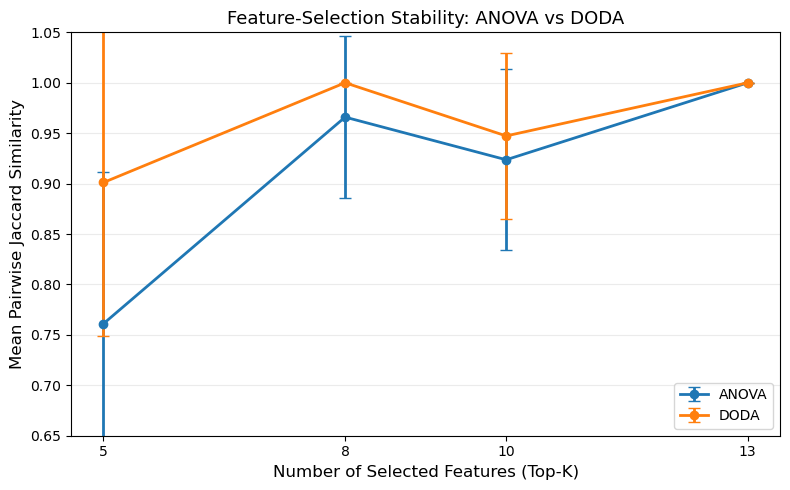

In [77]:
# =========================================================
# FIGURE 1: FEATURE-SELECTION STABILITY
# =========================================================

plt.figure(figsize=(8, 5))

for method in ["ANOVA", "DODA"]:

    temp = (
        stability_comparison_df[
            stability_comparison_df["Method"] == method
        ]
        .sort_values("Top_K")
    )

    plt.errorbar(
        temp["Top_K"],
        temp["Mean_Jaccard"],
        yerr=temp["SD_Jaccard"],
        marker="o",
        markersize=6,
        linewidth=2,
        capsize=4,
        label=method
    )

plt.xlabel("Number of Selected Features (Top-K)", fontsize=12)
plt.ylabel("Mean Pairwise Jaccard Similarity", fontsize=12)
plt.title("Feature-Selection Stability: ANOVA vs DODA", fontsize=13)

plt.xticks([5, 8, 10, 13])
plt.ylim(0.65, 1.05)

plt.grid(axis="y", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figure_1_feature_selection_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

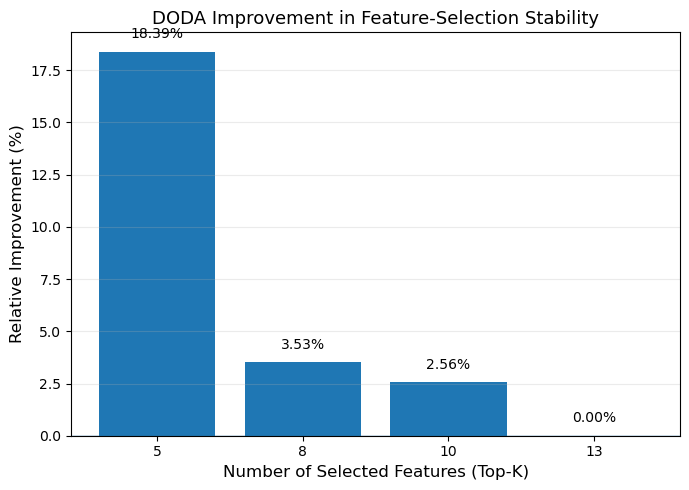

In [78]:
# =========================================================
# FIGURE 2: DODA STABILITY IMPROVEMENT
# =========================================================

plot_df = stability_improvement_table.copy()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    plot_df["Top-K"].astype(str),
    plot_df["Relative Improvement (%)"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Number of Selected Features (Top-K)", fontsize=12)
plt.ylabel("Relative Improvement (%)", fontsize=12)
plt.title("DODA Improvement in Feature-Selection Stability", fontsize=13)

for bar, value in zip(
    bars,
    plot_df["Relative Improvement (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figure_2_doda_stability_improvement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

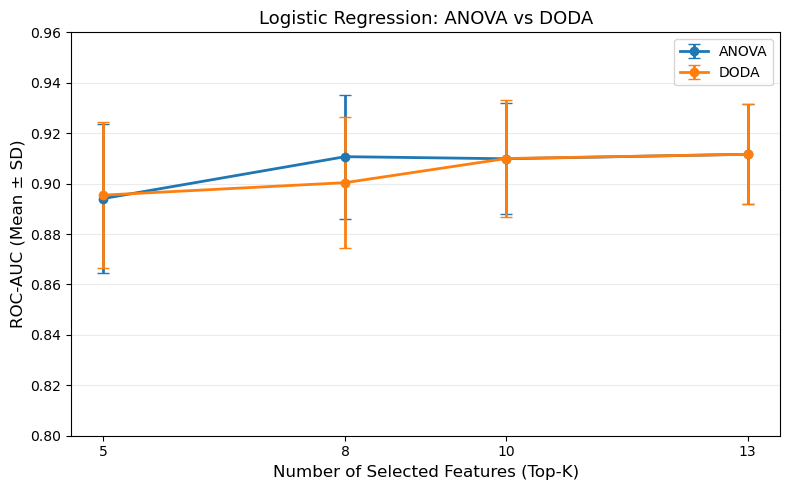

In [82]:
# =========================================================
# FIGURE 3A: LOGISTIC REGRESSION ROC-AUC
# =========================================================

temp = summary_df[
    summary_df["Model"].str.contains(
        "Logistic", case=False, na=False
    )
].copy()

plt.figure(figsize=(8, 5))

for method in ["ANOVA", "DODA"]:

    data = (
        temp[temp["Method"] == method]
        .sort_values("Top_K")
    )

    plt.errorbar(
        data["Top_K"],
        data["ROC_AUC_Mean"],
        yerr=data["ROC_AUC_STD"],
        marker="o",
        markersize=6,
        linewidth=2,
        capsize=4,
        label=method
    )

plt.xlabel("Number of Selected Features (Top-K)", fontsize=12)
plt.ylabel("ROC-AUC (Mean ± SD)", fontsize=12)
plt.title("Logistic Regression: ANOVA vs DODA", fontsize=13)

plt.xticks([5, 8, 10, 13])
plt.ylim(0.80, 0.96)

plt.grid(axis="y", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figure_3a_lr_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

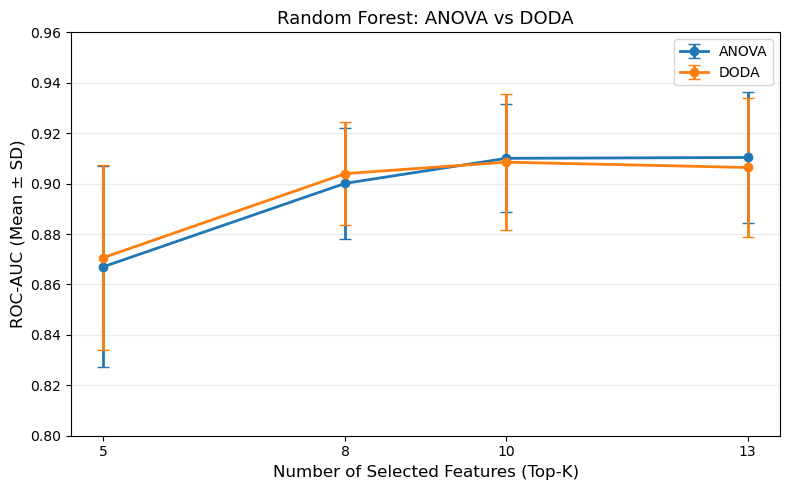

In [83]:
# =========================================================
# FIGURE 3B: RANDOM FOREST ROC-AUC
# =========================================================

temp = summary_df[
    summary_df["Model"].str.contains(
        "Random Forest", case=False, na=False
    )
].copy()

plt.figure(figsize=(8, 5))

for method in ["ANOVA", "DODA"]:

    data = (
        temp[temp["Method"] == method]
        .sort_values("Top_K")
    )

    plt.errorbar(
        data["Top_K"],
        data["ROC_AUC_Mean"],
        yerr=data["ROC_AUC_STD"],
        marker="o",
        markersize=6,
        linewidth=2,
        capsize=4,
        label=method
    )

plt.xlabel("Number of Selected Features (Top-K)", fontsize=12)
plt.ylabel("ROC-AUC (Mean ± SD)", fontsize=12)
plt.title("Random Forest: ANOVA vs DODA", fontsize=13)

plt.xticks([5, 8, 10, 13])
plt.ylim(0.80, 0.96)

plt.grid(axis="y", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figure_3b_rf_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

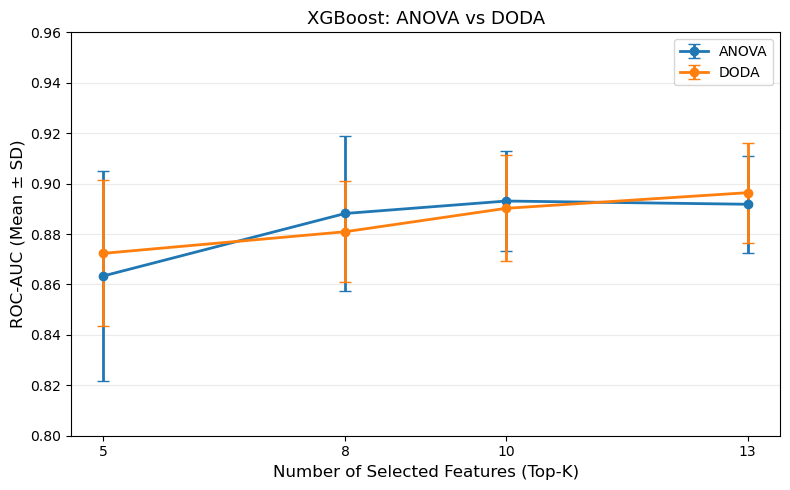

In [84]:
# =========================================================
# FIGURE 3C: XGBOOST ROC-AUC
# =========================================================

temp = summary_df[
    summary_df["Model"].str.contains(
        "XGBoost", case=False, na=False
    )
].copy()

plt.figure(figsize=(8, 5))

for method in ["ANOVA", "DODA"]:

    data = (
        temp[temp["Method"] == method]
        .sort_values("Top_K")
    )

    plt.errorbar(
        data["Top_K"],
        data["ROC_AUC_Mean"],
        yerr=data["ROC_AUC_STD"],
        marker="o",
        markersize=6,
        linewidth=2,
        capsize=4,
        label=method
    )

plt.xlabel("Number of Selected Features (Top-K)", fontsize=12)
plt.ylabel("ROC-AUC (Mean ± SD)", fontsize=12)
plt.title("XGBoost: ANOVA vs DODA", fontsize=13)

plt.xticks([5, 8, 10, 13])
plt.ylim(0.80, 0.96)

plt.grid(axis="y", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figure_3c_xgb_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

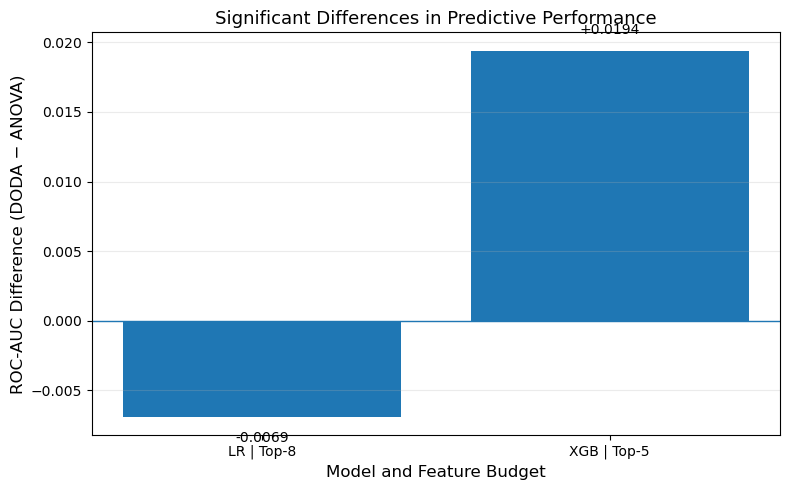

In [85]:
# =========================================================
# FIGURE 4: SIGNIFICANT PREDICTIVE DIFFERENCES
# =========================================================

sig_results = statistical_results_df[
    statistical_results_df["Holm_Adjusted_P"] < 0.05
].copy()

sig_results = sig_results.sort_values(
    "Holm_Adjusted_P"
)

# Create readable labels
sig_results["Comparison"] = (
    sig_results["Model"]
    + " | Top-"
    + sig_results["Top_K"].astype(str)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    sig_results["Comparison"],
    sig_results["Mean_Difference_DODA_minus_ANOVA"]
)

plt.axhline(0, linewidth=1)

plt.xlabel(
    "Model and Feature Budget",
    fontsize=12
)

plt.ylabel(
    "ROC-AUC Difference (DODA − ANOVA)",
    fontsize=12
)

plt.title(
    "Significant Differences in Predictive Performance",
    fontsize=13
)

for bar, value in zip(
    bars,
    sig_results["Mean_Difference_DODA_minus_ANOVA"]
):

    if value >= 0:
        y = value + 0.001
        va = "bottom"
    else:
        y = value - 0.001
        va = "top"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{value:+.4f}",
        ha="center",
        va=va,
        fontsize=10
    )

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figure_4_significant_predictive_differences.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Heart Disease Dataset — DODA Results Interpretation

## 1. Experimental Overview

The Heart Disease dataset was evaluated using a 5×5 Repeated Stratified Cross-Validation framework, resulting in 25 train-test evaluations. Two feature-selection approaches were compared:

* **ANOVA:** conventional statistical feature selection using the F-statistic.
* **DODA:** a domain-oriented feature-selection framework that integrates mathematical feature relevance with clinical knowledge through score fusion.

Four feature budgets were evaluated:

* Top-5
* Top-8
* Top-10
* Top-13

Three downstream machine-learning models were evaluated:

* Logistic Regression
* Random Forest
* XGBoost

Predictive performance was assessed using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Feature-selection stability was assessed using pairwise Jaccard similarity across the 25 repeated-CV runs.

Statistical comparisons between ANOVA and DODA were performed using paired Wilcoxon signed-rank tests. Cohen's *d* was used to quantify effect size, and Holm correction was applied to control for multiple comparisons.

---

# 2. Feature-Selection Stability

Feature-selection stability measures how consistently the same features are selected across different repeated-CV runs. A higher Jaccard similarity indicates greater consistency.

The results showed that DODA generally produced more stable feature subsets than ANOVA.

| Top-K | ANOVA Mean Jaccard | DODA Mean Jaccard | DODA Improvement |
| ----: | -----------------: | ----------------: | ---------------: |
|     5 |             0.7611 |            0.9011 |          +18.39% |
|     8 |             0.9659 |            1.0000 |           +3.53% |
|    10 |             0.9236 |            0.9473 |           +2.56% |
|    13 |             1.0000 |            1.0000 |               0% |

The largest improvement occurred at **Top-5**, where DODA increased the mean Jaccard similarity from 0.7611 to 0.9011, corresponding to an 18.39% relative improvement.

At **Top-8**, DODA achieved perfect stability across the 25 repeated-CV runs, with a mean Jaccard similarity of 1.0000 and zero standard deviation.

At Top-10, DODA also improved stability, although the improvement was smaller. At Top-13, both methods achieved perfect stability because all 13 available features were retained.

Therefore, the stability results indicate that the advantage of DODA is most evident when the feature budget is restricted.

---

# 3. Statistical Analysis of Feature-Selection Stability

Paired Wilcoxon signed-rank tests were performed using the per-run mean Jaccard similarity between feature subsets. Cohen's *d* was used to quantify the magnitude of the difference between methods.

After Holm correction for multiple comparisons:

| Top-K |  ANOVA |   DODA | Cohen's *d* | Holm-adjusted *p* | Significant |
| ----: | -----: | -----: | ----------: | ----------------: | ----------- |
|     5 | 0.7611 | 0.9011 |       1.548 |            0.0001 | Yes         |
|     8 | 0.9659 | 1.0000 |       0.633 |           <0.0001 | Yes         |
|    10 | 0.9236 | 0.9473 |       0.325 |            0.1190 | No          |
|    13 | 1.0000 | 1.0000 |       0.000 |            1.0000 | No          |

DODA demonstrated a **statistically significant improvement in feature-selection stability at Top-5 and Top-8**.

The Top-5 comparison produced a very large effect size (*d* = 1.548), indicating a substantial difference in stability between the two approaches.

At Top-8, DODA also demonstrated a statistically significant improvement with a moderate effect size (*d* = 0.633).

The Top-10 improvement was numerically positive but did not remain statistically significant after Holm correction. The Top-13 comparison was identical because all features were retained.

These findings provide evidence that incorporating clinical knowledge into the feature-selection process can improve the reproducibility of selected feature subsets, particularly when only a small number of features are retained.

---

# 4. Feature-Set Agreement Between ANOVA and DODA

Feature-set agreement was calculated by comparing the selected feature sets from ANOVA and DODA while ignoring the ordering of features.

| Top-K | Same Feature Sets | Different Feature Sets | Agreement | Difference |
| ----: | ----------------: | ---------------------: | --------: | ---------: |
|     5 |             13/25 |                  12/25 |       52% |        48% |
|     8 |              2/25 |                  23/25 |        8% |        92% |
|    10 |             10/25 |                  15/25 |       40% |        60% |
|    13 |             25/25 |                   0/25 |      100% |         0% |

The results demonstrate that DODA does not simply reproduce the feature subsets selected by ANOVA.

At Top-8, only **8% of repeated-CV runs produced the same feature set**, meaning that DODA selected a different subset from ANOVA in 92% of runs.

Importantly, this difference occurred alongside **perfect DODA stability at Top-8**.

This indicates that DODA can produce a feature subset that is both substantially different from the conventional statistical selector and highly reproducible across repeated-CV runs.

Therefore, the observed stability improvement is not merely a consequence of DODA reproducing ANOVA's feature rankings.

---

# 5. Predictive Performance

Predictive performance was evaluated using three downstream classifiers across Top-5, Top-8, Top-10, and Top-13 feature budgets.

Overall, DODA did **not** consistently outperform ANOVA across every model, metric, and feature budget.

Most differences in predictive performance were not statistically significant after Holm correction.

This indicates that the primary benefit of DODA in this experiment is **feature-selection stability rather than universally improved predictive performance**.

The predictive effect was dependent on both the downstream model and the number of selected features.

---

# 6. Significant Predictive Results

After performing paired Wilcoxon tests and applying Holm correction across the predictive-performance comparisons, only two comparisons remained statistically significant.

### Top-5 XGBoost

DODA achieved a higher mean ROC-AUC than ANOVA:

* ANOVA: **0.8628**
* DODA: **0.8822**
* Difference: **+0.0194**
* Cohen's *d*: **0.728**
* Holm-adjusted *p*: **0.0463**

Thus, DODA produced a statistically significant improvement in ROC-AUC for XGBoost when only five features were selected.

The effect size was moderate-to-large, suggesting that the difference was not only statistically detectable but also potentially meaningful in magnitude.

### Top-8 Logistic Regression

In contrast, ANOVA achieved a higher mean ROC-AUC than DODA:

* ANOVA: **0.9029**
* DODA: **0.8960**
* Difference: **−0.0069**
* Cohen's *d*: **−0.818**
* Holm-adjusted *p*: **0.0327**

Therefore, ANOVA significantly outperformed DODA for Logistic Regression at Top-8.

This opposite direction is important because it demonstrates that DODA's effect on predictive performance is **configuration-dependent**.

---

# 7. Overall Interpretation

The Heart Disease experiment provides evidence for two distinct effects of DODA.

### 7.1 Stability advantage

DODA consistently produced highly reproducible feature subsets, with statistically significant stability improvements at Top-5 and Top-8.

The strongest improvement occurred at Top-5:

> Mean Jaccard: 0.7611 → 0.9011
> Relative improvement: 18.39%
> Cohen's *d*: 1.548
> Holm-adjusted *p*: 0.0001

At Top-8, DODA achieved perfect feature-selection stability:

> Mean Jaccard = 1.0000

This suggests that the incorporation of clinical knowledge can constrain feature selection toward a more reproducible subset.

### 7.2 Predictive-performance effect is configuration-dependent

Unlike stability, predictive performance did not show a universal DODA advantage.

DODA significantly improved XGBoost ROC-AUC at Top-5, while ANOVA significantly outperformed DODA for Logistic Regression at Top-8.

Therefore, the results do **not** support the claim that DODA universally improves predictive performance.

Instead, they suggest that the influence of domain-informed feature weighting depends on:

* the number of retained features,
* the downstream learning algorithm, and
* the interaction between feature selection and model architecture.

---

# 8. Interpretation of Top-K Behaviour

The Top-K results provide an additional insight.

### Top-5

The strongest stability improvement occurred when only five features were retained.

This suggests that clinical weighting has the greatest influence when the feature-selection budget is highly constrained.

At the same time, DODA produced a significant improvement in XGBoost ROC-AUC, indicating that the domain-informed subset can be beneficial for at least some downstream models under strong dimensionality reduction.

### Top-8

DODA achieved perfect feature-selection stability and selected a substantially different feature set from ANOVA.

However, the predictive-performance advantage was not universal. Logistic Regression significantly favored ANOVA in ROC-AUC.

This demonstrates that a more stable feature subset does not necessarily guarantee higher predictive performance.

### Top-10

DODA continued to show numerically higher feature-selection stability than ANOVA, but the difference was not statistically significant after Holm correction.

Predictive-performance differences were also generally small and non-significant.

### Top-13

Top-13 represents the **full-feature condition**, since all 13 predictors are retained.

Consequently, both methods select the same feature set and feature-selection stability is trivially 1.0.

This condition should therefore be interpreted as a **full-feature baseline rather than evidence of feature-selection improvement**.

---

# 9. Key Research Finding

The central finding from the Heart Disease experiment is:

> **DODA substantially improves the stability and reproducibility of feature selection under restricted feature budgets, while its effect on predictive performance is model- and Top-K-dependent rather than universally superior to conventional ANOVA selection.**

This distinction is important because feature-selection quality should not be evaluated solely through predictive performance.

A feature-selection method may produce a highly reproducible subset without necessarily improving every downstream classifier. In this experiment, DODA's strongest and most consistent contribution was the **stability of the selected feature subsets**.

---

# 10. Research Implications

The findings suggest that integrating clinical knowledge into feature-selection pipelines can improve the reproducibility of selected predictors.

This may be particularly valuable in clinical machine-learning settings, where a feature-selection method should ideally identify predictors that remain consistent across different samples or resampling procedures.

However, the results also demonstrate that improved stability does not automatically translate into improved predictive performance.

Therefore, a clinically informed feature-selection framework should be evaluated using multiple dimensions:

1. **Predictive performance**
2. **Feature-selection stability**
3. **Clinical relevance**
4. **Robustness across downstream models**
5. **Behaviour under different feature budgets**

The DODA framework provides a mechanism for incorporating these considerations into a unified feature-selection process.

---

# 11. Limitations of the Heart Disease Experiment

Several limitations should be considered when interpreting these findings.

### Dataset size

The Heart Disease dataset contains only 303 observations. Consequently, although repeated stratified cross-validation provides multiple resampling estimates, the results may still be sensitive to the underlying sample size.

### Dataset-specific clinical weights

The clinical weighting scheme is based on domain knowledge for the Heart Disease predictors. The resulting behaviour may therefore differ across other clinical datasets.

### Multiple statistical comparisons

A relatively large number of predictive-performance comparisons were conducted. Holm correction was therefore applied to reduce the risk of false-positive findings.

### Stability metric

Jaccard similarity evaluates overlap between selected feature sets but does not directly assess whether one feature is clinically more meaningful than another. Therefore, stability should be interpreted alongside clinical validity.

### Top-13 condition

Because Top-13 retains all predictors, its perfect stability does not represent meaningful dimensionality-reduction performance.

---

# 12. Final Conclusion

The Heart Disease results demonstrate that DODA provides a clear advantage in **feature-selection stability**, particularly under constrained feature budgets.

DODA significantly improved stability at Top-5 and Top-8, with the largest effect observed at Top-5. At Top-8, DODA produced a perfectly stable feature subset across all repeated-CV runs while selecting a substantially different set of features from ANOVA.

However, predictive-performance improvements were not universal. DODA significantly improved XGBoost ROC-AUC at Top-5, whereas ANOVA significantly outperformed DODA for Logistic Regression at Top-8.

Therefore, the evidence supports the conclusion that:

> **DODA's principal contribution in the Heart Disease dataset is improved feature-selection stability and reproducibility, while predictive-performance benefits are configuration-dependent and vary according to the downstream model and feature-selection budget.**

This finding supports evaluating clinically informed feature-selection frameworks using both **predictive and stability-based criteria**, rather than relying exclusively on prediction metrics.
